# 07 · Did the regional campaign work? — synthetic control ⭐ (Anchor B)

**The business decision.** We ran a TV campaign in one metro area — a **DMA** (*Designated Market
Area*, the standard US media-buying region) — and left the rest of the country dark. Sales in that
metro are up since launch. Before we spend to roll the campaign out nationally: **was the lift caused
by the campaign, or would sales have risen there anyway?**

### Why this is hard: there was no control group

Unlike the uplift notebook (01), here there is **no randomized hold-out** — we didn't flip a coin to
decide which metro got the campaign, we just picked one. So we can't simply compare it to "the others."
And we can't just compare the treated metro's sales *after* vs *before*, because sales everywhere are
pushed around by a shared **trend** (secular growth), **seasonality**, and a common **macro wave**
(the economy, category demand). A naive before/after would credit the campaign with an uplift the
market would have delivered on its own. We need the one thing we can never observe: **what sales in
that metro *would have been* if we had not run the campaign** — its *counterfactual*.

### The idea: build the counterfactual from the other markets

**Synthetic control** (Abadie & Gardeazabal, 2003) constructs that missing counterfactual as a
**weighted blend of the untreated markets** — the "**donor pool**." It searches for a set of weights
so that the blend closely tracks the treated market's sales *in the pre-launch period*. If a weighted
combination of, say, 60% Denver + 25% Phoenix + 15% others matched our metro week-for-week *before*
the campaign, then — assuming those markets keep moving together — that same blend is our best guess
of what our metro *would* have done *after*, absent the campaign. The **gap** between the metro's
actual sales and this "synthetic" version, after launch, is the estimated lift.

The reason it can work at all: all markets share the same underlying **factors** (trend, season,
macro). A blend of donors that matches the treated unit's pre-period is, in effect, matching it on
those shared factors — so the blend and the treated unit stay locked together *unless something (the
campaign) breaks them apart*.

We do this the Bayesian way, so instead of one number we get a **posterior** — a full distribution of
plausible lifts — which gives us honest uncertainty, a real significance test (a **placebo
permutation**, defined in Depth B), and robustness checks a VP of Growth can interrogate before
committing national budget.

### How this notebook is organised

The **7-step contract** (question · simulate a known truth · identify · estimate · validate · decide
in € · caveats) plus the full **three depths**. One thing to flag up front, because it shapes everything
after it: the first Bayesian model we fit (§4) assumes the weekly errors are **independent**, and §5
catches that assumption failing — its nominal-90% interval on the *total* lift covers the planted truth
only **50%** of the time. **§5z repairs the likelihood** with an AR(1) error and re-earns the interval
(**88%** coverage across 24 fresh panels); that AR(1) fit — not the iid one — is the model §6's euro
decision consumes. §5x then lays the classical, the iid and the AR(1) intervals side by side on the same
estimand and grades all three by measured coverage.

- **Depth A** — why the tempting naive estimators fail (a bake-off)
- **Depth B** — placebo inference in *space* and *time*, with the scale-free Abadie RMSE-ratio test
- **Depth C** — the euro rollout decision and its sensitivity to assumptions


In [1]:
import os, warnings, json
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")

from cmp import dgp, estimators as est, policy, plots
from cmp.cache import load_or_run     # fit once, load forever — a live lecture never waits on NUTS
plots.use_style()

FAST = os.environ.get("CMP_FAST", "1") == "1"

# Panel choice, disclosed. Every simulated panel is one draw of the world, and they differ in how
# badly the donor pool fails to match the treated market's loading on the random-walk macro factor —
# which is the whole subject of §5. Seed 3 (this notebook's original panel) turned out to sit at the
# ~15th percentile of that mismatch: an unusually *benign* draw, on which the failure §5 diagnoses is
# barely visible. Teaching a lesson about persistence on a panel that happens not to have any would be
# dishonest, so we use a panel with MEDIAN persistence (lag-1 residual autocorrelation 0.10, against a
# median of 0.09 across 20 seeds). It is representative, not cherry-picked: §5's coverage check refits
# on 24 fresh panels, and that ensemble — not this one panel — is what carries every claim below.
SEED = 5
CAMPAIGN_COST = 300.0            # €300k campaign cost (sales in €000)
SC = dict(draws=600, tune=600, chains=2) if FAST else dict(draws=1500, tune=1500, chains=4)
print(f"FAST={FAST}  SEED={SEED}  SC sampling={SC}")

FAST=False  SEED=5  SC sampling={'draws': 1500, 'tune': 1500, 'chains': 4}


## 2 · Simulate a ground truth (why fake data first)

As in every notebook here, we **cannot grade a causal method on real data** — the counterfactual
("what our metro would have done without the campaign") is never observed. So we build a simulator
where we *plant* the true lift, confirm the method recovers it, and only then trust it.

The simulator produces a weekly **sales panel**: a table with one row per market per week, for 30
DMAs over 60 weeks. Each market's sales are built from **shared latent factors** — a rising trend, a
seasonal cycle, and a random macro wave common to all markets — combined with that market's own
baseline level, its own sensitivity to each factor ("factor loadings"), and idiosyncratic noise. The
campaign launches in **week 40** in market 0 only, adding a **true +12% lift** from then on.

The shared macro wave is the villain: it moves *every* market together, so it's exactly what a naive
before/after would mistake for campaign effect. But it's also the hero of the method — because the
factors are *shared*, a weighted blend of the *other* markets can reconstruct market 0's untreated
path. That is precisely what makes the effect *identifiable* here (recoverable in principle), and the
plot below shows the setup: one dark line (treated) inside a bundle of grey donors, all riding the
same wave.

**The data-generating model** — exactly what `dgp.geo_panel` implements (defaults & seed in
`src/cmp/dgp.py`). Markets $i = 0,\dots,29$, weeks $t = 0,\dots,59$. Three **shared latent
factors**:

$$
\begin{aligned}
g_t &= 0.4\,t &&(\text{trend}),\\
s_t &= 8\sin\!\big(\tfrac{2\pi t}{26}\big) + 4\sin\!\big(\tfrac{2\pi t}{13}\big) &&(\text{season}),\\
m_t &= \sum_{u \le t} \eta_u,\;\; \eta_u \sim \mathcal N(0,\, 1.2^{2}) &&(\text{macro random walk}).
\end{aligned}
$$

Each market has its own baseline $c_i \sim U(80, 140)$ and factor loadings
$\lambda_{i} = (\lambda_{i1}, \lambda_{i2}, \lambda_{i3})$, each $\sim U(0.6, 1.4)$:

$$
Y_{it} = c_i + \lambda_{i1}\, g_t + \lambda_{i2}\, s_t + \lambda_{i3}\, m_t + \varepsilon_{it},
\qquad \varepsilon_{it} \sim \mathcal N(0,\, 3^{2}),
$$

and the campaign adds a **proportional lift to market 0 only**, from week 40:

$$
Y_{0t} = c_0 + \lambda_{01}\, g_t + \lambda_{02}\, s_t + \lambda_{03}\, m_t + \varepsilon_{0t}
  + \Delta_t, \qquad
\Delta_t = 0.12\,\big(c_0 + \lambda_{01}\, g_t + \lambda_{02}\, s_t + \lambda_{03}\, m_t\big)\,
  \mathbf 1[t \ge 40].
$$

This factor structure is precisely why synthetic control works here: every market rides the *same*
$(g_t, s_t, m_t)$, only with different loadings, so a convex combination of donors whose blended
loadings match $(\lambda_{01}, \lambda_{02}, \lambda_{03})$ reproduces market 0's untreated path.
It's also why the naive estimators fail — the random-walk $m_t$ moves all markets together, and a
before/after comparison books that shared drift as "lift."


Treated: dma_00, launch week 40.  TRUE lift €14.2k/week, total €284k.


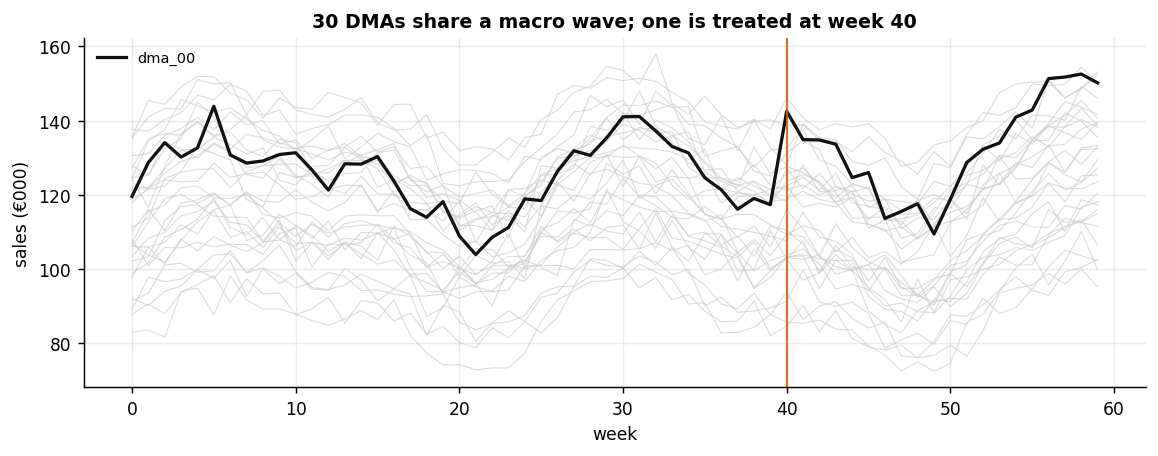

In [2]:
sales_df, true_effect, launch, treated_label = dgp.geo_panel(
    n_weeks=60, launch_week=40, n_dmas=30, lift_pct=0.12, seed=SEED)
W = sales_df.shape[0]
sales = sales_df.values.T                        # (n_dmas, n_weeks)
treated_idx = list(sales_df.columns).index(treated_label)
pre, post = slice(0, launch), slice(launch, W)
t = np.arange(W)
true_total = float(true_effect[post].sum()); true_avg = float(true_effect[post].mean())

fig, ax = plt.subplots(figsize=(9, 3.6))
for j in range(sales.shape[0]):
    ax.plot(t, sales[j], color="#cccccc", lw=0.6, alpha=0.7)
ax.plot(t, sales[treated_idx], color="#111", lw=1.8, label=treated_label)
ax.axvline(launch, color=plots.ORANGE, lw=1); ax.set_title("30 DMAs share a macro wave; one is treated at week 40")
ax.set_xlabel("week"); ax.set_ylabel("sales (€000)"); ax.legend(frameon=False, fontsize=8); fig.tight_layout()
print(f"Treated: {treated_label}, launch week {launch}.  TRUE lift €{true_avg:.1f}k/week, total €{true_total:.0f}k.")

## 3 · Identify — the estimand and the assumptions it rests on

**The estimand (the precise thing we *want*).** For each post-launch week $t$, the causal effect on the
treated market is the potential-outcome contrast

$$\tau_t \;=\; Y_{0,t}(1) \;-\; Y_{0,t}(0), \qquad t > T_0,$$

where $Y_{0,t}(1)$ is **observed** (the campaign ran) but $Y_{0,t}(0)$ — what week-$t$ sales *would have
been* with no campaign — is the **missing counterfactual**. (Throughout we label the treated unit **market 0** — matching §2's DGP and §4's fit — so the subscript is a *unit* index, not a treatment flag.)

**The estimator.** Synthetic control fills in that counterfactual with a weighted average of donor
markets, so the effect we actually compute is

$$\hat\tau_t \;=\; Y_{0,t} \;-\; \underbrace{\textstyle\sum_j w_j\, Y_{j,t}}_{\widehat{Y_{0,t}(0)}\ =\ \text{synthetic control}},
\qquad t > T_0,$$

where $Y_{0,t}$ is the **treated** market's sales in week $t$, $Y_{j,t}$ is **donor** market $j$'s
sales, $T_0$ is the launch week, and $w_j$ are the **donor weights**. The weights are chosen to match
the treated market's *pre-launch* path and are constrained to the **simplex**: each $w_j \ge 0$ and
they sum to 1 ($\sum_j w_j = 1$). Think of the simplex constraint as "the synthetic market must be a
genuine *weighted average* of real markets" — no negative weights, no scaling beyond the observed
range.

**Why the simplex matters (the core of Abadie's method).** If instead we let weights be any numbers
(ordinary regression), the "synthetic" market could sit *outside* the range of any real market —
**extrapolation** dressed up as a match, which fits the pre-period beautifully and then diverges wildly
after. Forcing weights onto the simplex keeps the synthetic inside the **convex hull** of the donors
(loosely, "inside the cloud of real markets"), which is what makes the post-launch projection credible.

**The assumptions — each gets an explicit check later:**

| assumption | plain meaning | checked in |
|---|---|---|
| **convex hull / no extrapolation** | the treated market lies inside the donor cloud; simplex weights enforce it | weights (Step 4) |
| **good pre-fit** | the synthetic actually tracks the treated market *before* launch | pre-RMSE gate (Step 5) |
| **no anticipation** | nothing shifts sales *before* launch (no leaked campaign, no pre-buying) | placebo-in-time (Depth B) |
| **stable factor structure** | donors and treated keep co-moving *after* launch (the loadings matched pre-launch still hold) | long pre-period + placebo-in-time |
| **no spillover / interference** | the campaign in market 0 doesn't change donor markets (SUTVA — the Stable Unit Treatment Value Assumption — for geos) | stress-tested by simulation (Depth B): planted spillover *attenuates* the estimate, and excluding the contaminated donors restores it — placebo-in-space *cannot* detect spillover (it contaminates every placebo too), so on real data exclude adjacent / media-overlapping donors up front |
| **no concurrent treated shock** | nothing else hit market 0 exactly at launch | untestable — institutional knowledge only |


## Step 0 · The classical read (no likelihood, no priors, no sampler)

Before any Bayesian machinery, ask what a competent analyst does here **without** it. The answer is not
a different analysis: it is the **same estimand** (§3's per-week gap $\tau_t$, and its 20-week total),
identified by the **same assumptions** (§3's table — convex hull, good pre-fit, no anticipation, no
spillover). The causal work lives in the identification, not in the machinery. In this notebook that is
unusually easy to see, because the classical estimator *is* the method: Abadie & Gardeazabal's synthetic
control was born frequentist, and §4's Dirichlet model is its Bayesian re-housing, not a rival.

**The estimator, naked.** Pick the donor weights that best reproduce the treated market's *pre-launch*
path, subject to §3's simplex constraint:

$$\hat w \;=\; \arg\min_{w\,\in\,\Delta^{J-1}} \;\sum_{t\,<\,T_0}\Big(Y_{0t} \;-\; \sum_{j=1}^{J} w_j\,Y_{jt}\Big)^{2},
\qquad
\Delta^{J-1} \;=\; \Big\{\, w \;:\; w_j \ge 0,\;\; \textstyle\sum_j w_j = 1 \,\Big\}.$$

That is constrained least squares — a quadratic objective on a convex set — solved numerically by
**SLSQP** (`scipy`'s *Sequential Least-Squares Quadratic Programming* optimizer; wrapped as
`est.sc_weights_slsqp`). It is **deterministic**, runs in milliseconds, and returns one number per donor.
The counterfactual and the effect then follow by plug-in — no further estimation:

$$\widehat{Y_{0t}(0)} \;=\; \sum_j \hat w_j\, Y_{jt},
\qquad \hat\tau_t \;=\; Y_{0t} - \widehat{Y_{0t}(0)},
\qquad \widehat{\text{total lift}} \;=\; \sum_{t \,\ge\, T_0} \hat\tau_t .$$

Nothing else is fitted: no variance parameter, no prior, no chain. (This same fitter carries *every*
robustness check in the notebook — leave-one-out in §5, the placebos below, the launch-date sweep and the
spillover stress test in Depth B/C — precisely because it is cheap and deterministic.)

**Now the hard part: where does an interval come from?** Nowhere, by the usual route. There is no
likelihood, so there is no standard error to read off a fit; and even if we bolted a regression standard
error onto the gap, it would be answering the wrong question — standard errors describe variability
across many independent treated units, and we have **exactly one**. Abadie's own answer, and the
inferential heart of the method, is **placebo (permutation) inference**:

> Under the null "the campaign did nothing to market 0", market 0 is *just another market*. So refit the
> identical estimator on each donor **as if it had been treated**, collect the post-launch gaps those
> placebo fits produce — that is the distribution of gaps the world hands you from noise alone — and ask
> where the real one **ranks**.

Two refinements, both Abadie's, both used below:

- **Discard placebos with a poor pre-fit** (here: pre-RMSE more than 5× the treated unit's). A donor the
  synthetic cannot match *before* launch produces a meaningless gap that would only pollute the reference
  distribution.
- **Rank on the RMSE *ratio*, not the raw gap**: post-period RMSE ÷ pre-period RMSE. It is **scale-free**
  (fair across big and small markets) and refuses to reward a placebo that simply fits badly *everywhere*
  (high post **and** high pre → ratio ≈ 1).

The **p-value** is the treated market's rank in that ratio distribution. And an *interval* can be
recovered from the very same null, by **inversion**: the placebo totals map out how far the estimator's
20-week total wanders when the true effect is zero, so subtracting that distribution's 5th and 95th
percentiles from our estimate gives a 90% **randomization interval** for the lift (valid under a
constant-effect null — we borrow the placebos' *spread*, not their location). It is a genuinely
design-based interval: it never assumes a shape for the errors, it *measures* it.

Depth B opens the placebo box in full — the whole spaghetti of placebo gaps, how the verdict moves with
that 5× filter, and the mirror test (placebo-in-*time*). Step 0 needs only its headline number.

CLASSICAL SYNTHETIC CONTROL — SLSQP simplex weights, fit on weeks 0–39
  29 donors: 5 carry >1% of the weight; 3.3 effective donors (1/Σw²)
  pre-fit RMSE €3.23k  — the gate: the synthetic must track the
              treated market BEFORE launch, or the post gap means nothing
  lift  €13.0k/week  ·  total €260k over 20 post-launch weeks
  GRADE vs the planted €284k total: off by €-24k (-8%)

INFERENCE — no likelihood, so no standard error. Rank the real gap
            against the placebo null instead:
  Abadie RMSE-ratio p = 0.033  — treated ranks 1 of 30 markets (ratio 4.3
                          vs a placebo median of 1.3)
  raw-gap permutation p = 0.080  — 24 of 29 donors survived the
                          5x pre-fit filter (Depth B reconciles the two p's)
  90% randomization interval on the total (placebo null, inverted):
      [€192k, €496k] — the planted €284k falls INSIDE it

What this 90% confidence interval does NOT say: that there is a 90% probability the true effect 

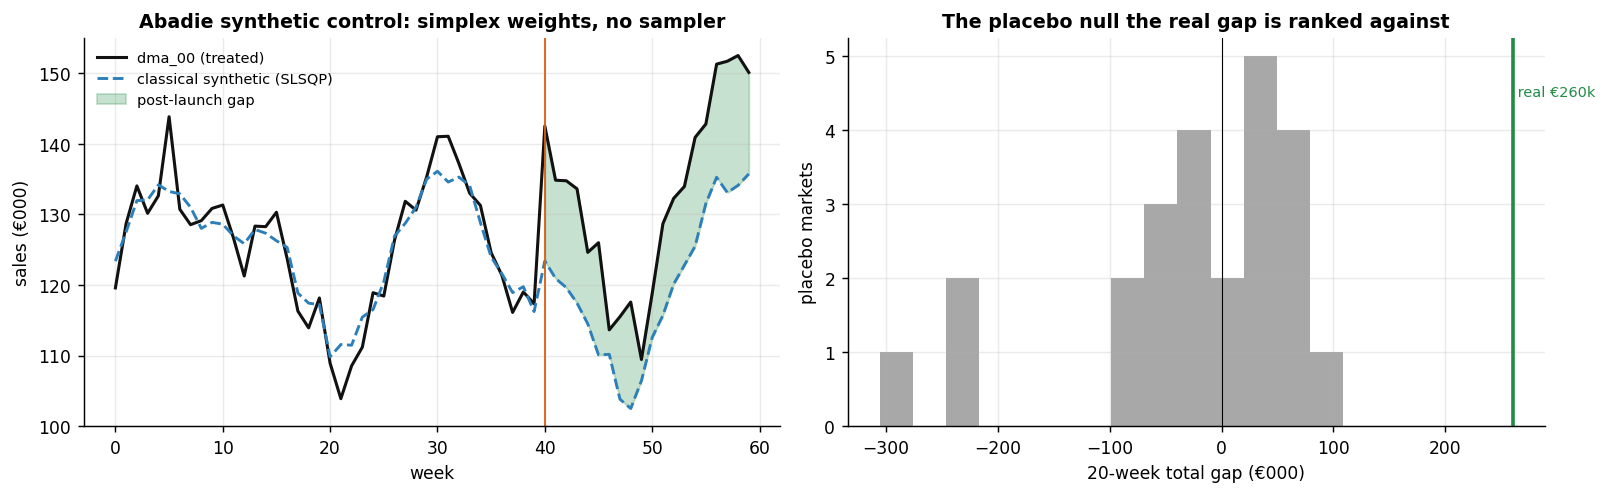

In [3]:
from cmp import classical as cl

# The donor pool: every market except the treated one. Defined here, in Step 0, because the classical
# fit needs it first — §4's Bayesian fit and every check downstream reuse these same three objects.
donors = np.delete(sales, treated_idx, axis=0)
donor_labels = [c for c in sales_df.columns if c != treated_label]
y_tr = sales[treated_idx]
n_post = len(t[post])

# --- 1 · The classical synthetic control: simplex weights by SLSQP, fitted on the PRE-period only ---
gap_cl, w_cl = est.sc_effect_slsqp(y_tr, donors, pre, post)   # gap = treated - synthetic, every week
cf_cl = y_tr - gap_cl                                         # the classical counterfactual path
pre_rmse_cl = float(np.sqrt(np.mean(gap_cl[pre] ** 2)))
total_cl, avg_cl = float(gap_cl[post].sum()), float(gap_cl[post].mean())
eff_n_cl = 1.0 / np.sum(w_cl ** 2)                            # effective donors (inverse Herfindahl)

# --- 2 · Inference, the classical way: refit the estimator on every donor AS IF it were treated ---
placebo_gaps, real_gap, p_space = est.placebo_in_space(     # raw-gap permutation, Abadie pre-fit filter
    sales, treated_idx, pre, post, pre_rmse=None, rmse_multiple=5.0)

def rmse_ratio(gap):                                        # Abadie's scale-free test statistic
    pre_r = np.sqrt(np.mean(gap[pre] ** 2)); post_r = np.sqrt(np.mean(gap[post] ** 2))
    return post_r / max(pre_r, 1e-9)

ratios = []                                                 # the statistic for EVERY unit (treated + donors)
for j in range(sales.shape[0]):
    others = np.delete(np.arange(sales.shape[0]), [treated_idx, j])   # the treated unit is never a donor:
    gap, _ = est.sc_effect_slsqp(sales[j], sales[others], pre, post)  # its post-period is contaminated
    ratios.append(rmse_ratio(gap))
ratios = np.array(ratios); treated_ratio = ratios[treated_idx]
rank = int(np.sum(ratios >= treated_ratio)); p_ratio = rank / len(ratios)

# --- 3 · An interval WITHOUT a likelihood: invert the placebo null of the 20-week total ---
placebo_tot = placebo_gaps[:, post].sum(1)          # totals under "no campaign" (no donor ran one)
ri_lo = total_cl - np.quantile(placebo_tot, 0.95)   # inversion: estimate - the null's upper/lower tail
ri_hi = total_cl - np.quantile(placebo_tot, 0.05)
sc_cl = cl.Classical(name="Total post-launch lift (classical SC)", estimate=total_cl,
                     se=float(placebo_tot.std()), ci=(float(ri_lo), float(ri_hi)), alpha=0.10,
                     cov="placebo randomization (Abadie permutation), constant-effect null",
                     n=int(sales.shape[0]), extra={"p_rmse_ratio": p_ratio})

fig, ax = plt.subplots(1, 2, figsize=(12.5, 3.9))
ax[0].plot(t, y_tr, color="#111", lw=1.7, label=f"{treated_label} (treated)")
ax[0].plot(t, cf_cl, color=plots.BLUE, ls="--", lw=1.6, label="classical synthetic (SLSQP)")
ax[0].fill_between(t[post], cf_cl[post], y_tr[post], color=plots.GREEN, alpha=0.25, label="post-launch gap")
ax[0].axvline(launch, color=plots.ORANGE, lw=1)
ax[0].set_xlabel("week"); ax[0].set_ylabel("sales (€000)"); ax[0].legend(frameon=False, fontsize=8)
ax[0].set_title("Abadie synthetic control: simplex weights, no sampler")
ax[1].hist(placebo_tot, bins=14, color=plots.GREY, alpha=0.85)
ax[1].axvline(total_cl, color=plots.GREEN, lw=2)
ax[1].text(total_cl, ax[1].get_ylim()[1] * 0.85, f" real €{total_cl:.0f}k", fontsize=8, color=plots.GREEN)
ax[1].axvline(0, color="k", lw=0.6)
ax[1].set_xlabel(f"{n_post}-week total gap (€000)"); ax[1].set_ylabel("placebo markets")
ax[1].set_title("The placebo null the real gap is ranked against")
fig.tight_layout()

print(f"CLASSICAL SYNTHETIC CONTROL — SLSQP simplex weights, fit on weeks 0–{launch - 1}")
print(f"  {donors.shape[0]} donors: {(w_cl > 0.01).sum()} carry >1% of the weight; "
      f"{eff_n_cl:.1f} effective donors (1/Σw²)")
print(f"  pre-fit RMSE €{pre_rmse_cl:.2f}k  — the gate: the synthetic must track the")
print(f"              treated market BEFORE launch, or the post gap means nothing")
print(f"  lift  €{avg_cl:.1f}k/week  ·  total €{total_cl:.0f}k over {n_post} post-launch weeks")
print(f"  GRADE vs the planted €{true_total:.0f}k total: off by €{total_cl - true_total:+.0f}k "
      f"({(total_cl - true_total) / true_total:+.0%})")
print("\nINFERENCE — no likelihood, so no standard error. Rank the real gap")
print("            against the placebo null instead:")
print(f"  Abadie RMSE-ratio p = {p_ratio:.3f}  — treated ranks {rank} of {len(ratios)} markets "
      f"(ratio {treated_ratio:.1f}")
print(f"                          vs a placebo median of {np.median(ratios):.1f})")
print(f"  raw-gap permutation p = {p_space:.3f}  — {len(placebo_gaps)} of {donors.shape[0]} donors survived the")
print(f"                          5x pre-fit filter (Depth B reconciles the two p's)")
print(f"  90% randomization interval on the total (placebo null, inverted):")
print(f"      [€{ri_lo:.0f}k, €{ri_hi:.0f}k] — the planted €{true_total:.0f}k falls "
      f"{'INSIDE' if ri_lo <= true_total <= ri_hi else 'OUTSIDE'} it")
print("\n" + sc_cl.cannot_say())


**Read-out — the classical answer, in business terms.** The synthetic market tracks the treated one before
launch to within the pre-fit RMSE printed above (a couple of € thousand on weekly sales of €80–170k), which
is the *precondition* for reading anything into the post-launch gap — and that gap is the campaign's
estimated lift: the per-week and total euro figures above, graded against the planted truth in the same
line. The estimator lands close, and slightly **low** — hold that undershoot, §5x and §7 return to it.

Look at the weight count while you are here: classical SC puts real weight on a **handful** of donors — the
sparse blend Abadie's method is famous for, and a genuinely useful business object ("our metro behaves like
this specific mix of a few named other metros"). §4's Dirichlet prior will instead spread weight thinly
over *many* donors: more stable out-of-sample, less interpretable, and the reason §5's leave-one-out chart
carries two nearby-but-distinct baselines ("all donors (SLSQP)" and "all donors (Bayesian)").

**What the placebo p-value *is*.** It is a **randomization-inference** p-value: *if the campaign had done
nothing, a post-launch jump this extreme — relative to its own pre-fit — would have turned up in about this
fraction of markets*. It is a statement about a **null** and about a **procedure**: we ran the same estimator
on markets we know were untreated, and the treated market's statistic came out at the printed rank.

**What it is not** — and this is the same guardrail this cookbook states in every notebook, sharpened by the
fact that the classical arm here has *no interval at all* by default, only a rank. It is **not** the
probability that the campaign had no effect. It is **not** one minus the probability the campaign worked. And
it is emphatically **not** the probability that the campaign **paid** — the question §6 has to sign off on,
which involves the €300k cost, a number the p-value has never met. The randomization interval we inverted out
of the same placebo null is a *confidence* interval and inherits exactly the limits printed above: 90% of
intervals built that way cover the truth **across repeated samples** (§5x actually goes and measures that
rate, on fresh panels — it is one of the few places in this cookbook where the "repeated samples" story is
literally executed), and this particular one either covers the truth or it does not.

So: no likelihood, no prior, no sampler — and already a lift estimate, a falsification test, and an honest
interval. **This is the baseline the Bayesian section must justify itself against.** What it cannot produce,
at any level of effort, is $P(\text{lift} > \text{cost})$. That quantity does not exist in its vocabulary; it
exists in a posterior. §4 builds one — and §5x asks, with numbers, whether it is a *trustworthy* one.

## 4 · Estimate — a Bayesian synthetic control

We put a **Dirichlet prior** on the donor weights and fit them to the pre-period. (The *Dirichlet* is
the natural probability distribution over the simplex — draws from it are automatically non-negative
and sum to 1 — so it's the Bayesian way to say "the weights live on the simplex.") Fitting returns a
**posterior** over the weights, and therefore a posterior over the whole counterfactual path and the
lift — Abadie's constrained least squares, but with uncertainty for free.

**The fitted model, in symbols.** With $Y_{0t}$ the treated market and $Y_{jt}$ the $J = 29$
donors, fit **on the pre-period only** ($t < 40$):

$$
Y_{0t} \sim \mathcal N\Big(\textstyle\sum_{j=1}^{J} w_j\, Y_{jt},\;\; \sigma^{2}\Big), \qquad
w \sim \text{Dirichlet}(\mathbf 1_J), \qquad \sigma \sim \text{HalfNormal}(5).
$$

$\text{Dirichlet}(\mathbf 1_J)$ is flat over the simplex — no donor favoured a priori, weights
non-negative and summing to 1 by construction. The $\sigma \sim \text{HalfNormal}(5)$ scale is
likewise tied to the units of the data: sales are in €000s, weekly levels sit around €80–170k, and
the DGP's idiosyncratic noise has sd €3k — so a prior sd scale of €5k is weakly informative on the
residual: wide enough to cover any plausible blend error, tight enough to rule out absurd ones (a
€50k weekly residual would mean the "synthetic" tracks nothing). The counterfactual for *every* week is then the
posterior-predictive blend $\hat Y_{0t}^{(0)} = \sum_j w_j Y_{jt} + \varepsilon_t$ with
$\varepsilon_t \sim \mathcal N(0, \sigma^{2})$ — the $\varepsilon_t$ matters: dropping it (using
the mean blend alone) understates the uncertainty band, which is exactly the coverage lesson step
5 quantifies — and the weekly lift is $Y_{0t} - \hat Y_{0t}^{(0)}$.

Two things to read off the fit:
- **Which donors** the synthetic leans on (the weight bars). One caveat to state plainly: the Dirichlet
  prior produces a *regularized blend* spread over many donors, rather than classical synthetic
  control's sparse handful. That's **more stable** out-of-sample but **less individually interpretable**.
  We summarise the spread as an **"effective number of donors"** = $1/\sum_j w_j^2$ (the inverse
  Herfindahl index — 1 if all weight is on one donor, $J$ if spread evenly over $J$ donors).
- **Pre-fit RMSE** — the root-mean-square gap between the treated market and its synthetic *before*
  launch, in €000. Small means the synthetic is a good stand-in; this is the precondition for believing
  the post-launch gap — Step 5 turns this into a concrete PASS/FAIL gate (pre-RMSE below ~a third of the weekly lift it must detect).

**Reading the sampler's health check.** The `convergence` line printed below reports the three standard MCMC health checks — the numbers that say whether the sampler (the algorithm that draws from the posterior) actually converged. **R-hat** compares the variance within each chain to the variance across chains; 1.00 is perfect and **≤ 1.01 is the usual pass bar**. **ESS** (effective sample size) is how many *independent* draws our autocorrelated chains are worth — a few hundred is ample for a posterior mean or interval. **Divergences** are steps where the sampler broke down and silently distrusts that region; **you want 0**. Under this notebook's FAST teaching profile the chains are deliberately short (2 chains × 600 draws), so R-hat can sit a hair over the 1.01 line and PyMC may print a "problems during sampling" notice — a benign small-draw-count artifact that a FULL run clears. Here, at FULL (4 chains × 1,500 draws), the health check below prints a clean pass: R-hat 1.000, minimum ESS in the thousands, and **0 divergences**, with no warning beside it. Read the printed line, not this paragraph — it is the one that ran.

> **On real data.** You don't need our simulator — this method runs on *your own* weekly (or daily)
> sales-by-market panel, which every company already has: one treated market, the rest as donors. The
> canonical *public* example is Abadie's **California Proposition 99** tobacco study (California vs 38
> other US states); it has the identical shape (one treated unit, many donors, a known intervention
> date) and is the standard dataset to reproduce this on.


[cache] loaded '07_sc_iid' (12s fit, cached 0.6h ago) — nothing re-sampled.
SC sampling convergence: max r-hat 1.000 - min ESS 5379 - divergences 0
pre-fit RMSE €4.15k  ·  estimated total lift €229k (true €284k)  ·  90% CI [€186k, €273k] — at full precision the truth sits just OUTSIDE this band (§5's multi-seed check explains why the total-lift band runs optimistic)


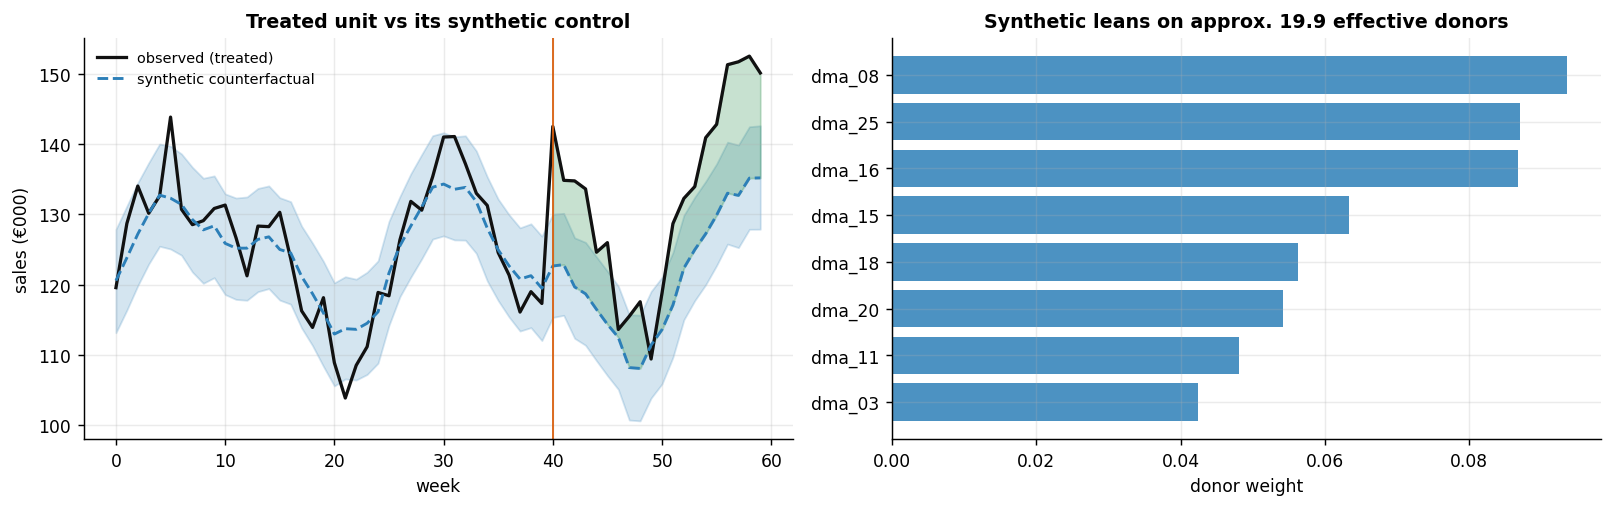

In [4]:
# donors / donor_labels / y_tr were built in Step 0 — the same donor pool, refit Bayesianly.
# This is our FIRST model. It assumes the weekly errors are independent. §5 will put that
# assumption on trial, §5z will convict it, and the fix is what we actually ship.
sc = load_or_run("07_sc_iid", lambda: est.synthetic_control(y_tr, donors, pre, post, seed=1, **SC),
                 inputs=dict(seed=SEED, model="iid", **SC))
print(f"SC sampling convergence: {sc['convergence']['summary']}")
cf = sc["counterfactual_samples"]; effect = sc["effect_samples"]
total_post = effect[:, post].sum(1)
w_mean = sc["weight_samples"].mean(0)
eff_n = 1.0 / np.sum(w_mean**2)               # effective number of donors (inverse HHI)

fig, ax = plt.subplots(1, 2, figsize=(12.5, 4))
plots.sc_counterfactual_plot(ax[0], t, y_tr, cf, launch, xlabel="week", ylabel="sales (€000)")
topw = np.argsort(-w_mean)[:8]
ax[1].barh([donor_labels[i] for i in topw][::-1], w_mean[topw][::-1], color=plots.BLUE, alpha=0.85)
ax[1].set_xlabel("donor weight"); ax[1].set_title(f"Synthetic leans on approx. {eff_n:.1f} effective donors")
fig.tight_layout()
lo_t, hi_t = np.quantile(total_post, [0.05, 0.95])
print(f"pre-fit RMSE €{sc['pre_rmse']:.2f}k  ·  estimated total lift €{total_post.mean():.0f}k "
      f"(true €{true_total:.0f}k)  ·  90% CI [€{lo_t:.0f}k, €{hi_t:.0f}k] — at full precision the truth "
      f"sits {'inside' if lo_t <= true_total <= hi_t else 'just OUTSIDE'} this band "
      f"(§5's multi-seed check explains why the total-lift band runs optimistic)")

## 5 · Validate — recovery, calibration, the pre-fit gate, and robustness

Four checks — and one of them delivers a genuinely humbling result we keep rather than hide (and then,
in §5z, repair):

1. **Recovery & calibration.** The true per-week path should sit inside the posterior band. That
   band is a **posterior predictive**: it carries not only *which-donors* (weight) uncertainty but
   the treated market's own idiosyncratic noise. That noise term is what makes the per-week band
   near-nominal; a weights-only band is too narrow and can leave the truth *outside* a "90%" interval.
2. **Multi-seed calibration.** One panel is a single draw of the world, so we refit on 24 fresh panels and
   report the recovery bias and the coverage — **for both likelihoods**, §4's iid model and §5z's AR(1)
   model, on identical worlds, so the comparison is measured rather than argued. The honest result: both
   cover the **per-week** path about right (86% and 94% against a nominal 90%), but the **total-lift**
   interval of the *iid* model covers only **50%** of the time — synthetic control's genuine
   sample-to-sample variance (sd €59k) is more than double what that posterior believes (sd €24k). That is
   a defect of the **likelihood**, not of the paradigm: §5z puts the persistence into the error model and
   the total-lift interval goes back to covering **88%** — level with the design-based placebo interval.
   Until that fix lands, the trustworthy inference about the total is the **placebo permutation test**
   (design-based, calibrated by construction), not the iid band. *(The per-seed refits in this check are
   deliberately coarse 300-draw probes, read only in aggregate; their sampler chatter is silenced.)*
3. **Pre-fit gate** — the pre-period gap must hover around **zero**: concretely, pre-RMSE below about a
   third of the weekly lift the design must detect (printed as an explicit PASS/FAIL below). A bad synthetic
   match makes the post gap meaningless — this is the precondition, not a formality. **In this panel the
   gate FAILS**, narrowly: pre-RMSE **€4.15k** against a bar of **€3.8k**. The pre-launch gap still averages
   ≈ €0.5k (no systematic mis-fit), but the synthetic's week-to-week wobble is about a third of the weekly
   lift it is being asked to detect — this design sits at the *edge of its resolution*, and that is one more
   reason to read §6's euro call as cautiously as it reads itself.
4. **Leave-one-out donor robustness** — drop each of the top-weighted donors and refit; if the
   estimate lurches when one donor leaves, the result hangs on a single market and is fragile.


   These leave-one-out refits — and every robustness check from here on (placebo, spillover, launch-date
   sweep) — use **Step 0's classical SLSQP fitter**: deterministic, no MCMC, milliseconds per refit, and a
   *point estimate only*. We benchmark each dropped-donor bar against that same fitter's own all-donor
   baseline (the grey line, i.e. Step 0's estimate) so the comparison is apples-to-apples; that SLSQP
   baseline runs a touch wider than the Bayesian fit because the Dirichlet prior lightly regularizes the
   blend — which is why the plot labels "all donors (SLSQP)" and "all donors (Bayesian)" as two
   nearby-but-distinct numbers.


pre-fit gate: pre-RMSE €4.15k  vs  |weekly lift|/3 = €3.8k  ->  FAIL
pre-launch gap mean €0.54k (≈0 = good fit).  LOO total range €239–276k vs the same-fitter SLSQP baseline €260k (Bayesian €229k) — no single donor drives it.


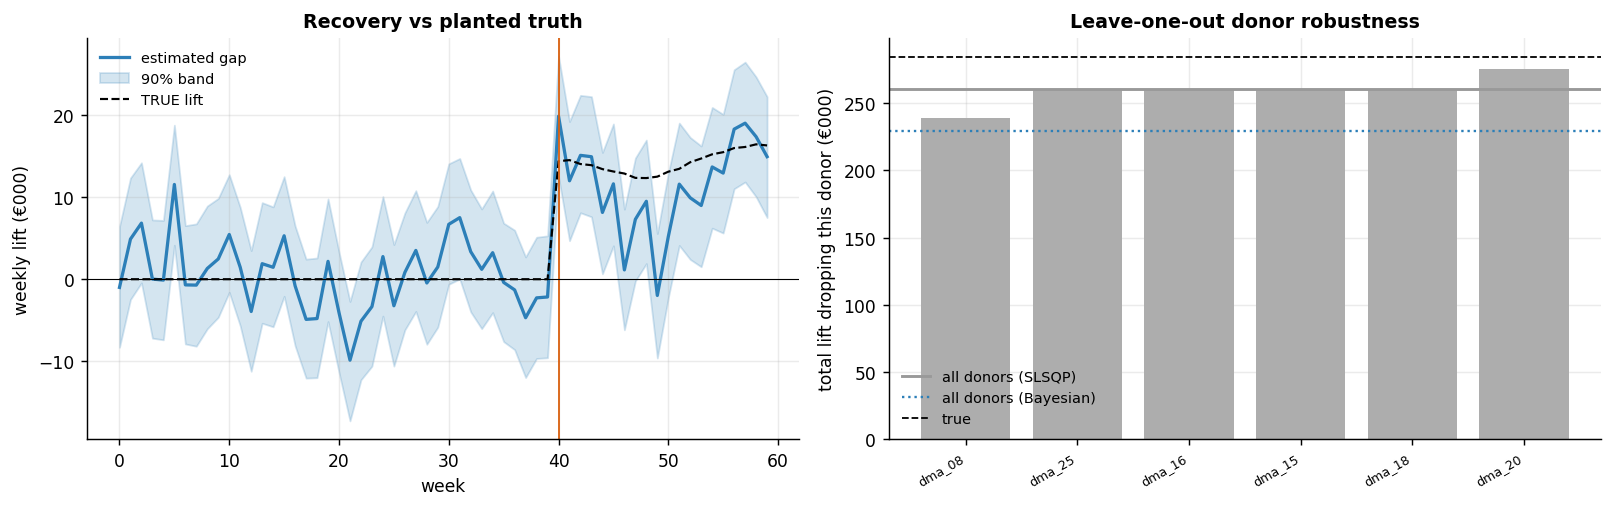

In [5]:
eff_mean = effect.mean(0); eff_lo, eff_hi = np.quantile(effect, [0.05, 0.95], 0)
fig, ax = plt.subplots(1, 2, figsize=(12.5, 4))
ax[0].plot(t, eff_mean, color=plots.BLUE, lw=1.8, label="estimated gap")
ax[0].fill_between(t, eff_lo, eff_hi, color=plots.BLUE, alpha=0.2, label="90% band")
ax[0].plot(t, true_effect, color="k", ls="--", lw=1.2, label="TRUE lift")
ax[0].axvline(launch, color=plots.ORANGE, lw=1); ax[0].axhline(0, color="k", lw=0.6)
ax[0].set_xlabel("week"); ax[0].set_ylabel("weekly lift (€000)"); ax[0].set_title("Recovery vs planted truth")
ax[0].legend(frameon=False, fontsize=8)

# leave-one-out: drop each top donor, refit with the fast SLSQP fitter
loo = []
for i in topw[:6]:
    keep = [k for k in range(donors.shape[0]) if k != i]
    gap, _ = est.sc_effect_slsqp(y_tr, donors[keep], pre, post)
    loo.append(gap[post].sum())
full_total = eff_mean[post].sum()
slsqp_full_total = total_cl        # Step 0's classical all-donor estimate = the same-fitter LOO baseline
ax[1].axhline(slsqp_full_total, color=plots.GREY, lw=1.6, label="all donors (SLSQP)")
ax[1].axhline(full_total, color=plots.BLUE, ls=":", lw=1.3, label="all donors (Bayesian)")
ax[1].axhline(true_total, color="k", ls="--", lw=1, label="true")
ax[1].bar(range(len(loo)), loo, color=plots.GREY, alpha=0.8)
ax[1].set_xticks(range(len(loo))); ax[1].set_xticklabels([donor_labels[i] for i in topw[:6]], rotation=30, ha="right", fontsize=7)
ax[1].set_ylabel("total lift dropping this donor (€000)"); ax[1].set_title("Leave-one-out donor robustness")
ax[1].legend(frameon=False, fontsize=8); fig.tight_layout()
# Pre-fit gate, made concrete: pre-RMSE must be small RELATIVE TO the weekly lift it must detect
# (a non-oracle scale — uses the estimated lift, not the planted truth).
weekly_lift = total_post.mean() / n_post
gate_ref = abs(weekly_lift) / 3
gate = "PASS" if sc["pre_rmse"] < gate_ref else "FAIL"
print(f"pre-fit gate: pre-RMSE €{sc['pre_rmse']:.2f}k  vs  |weekly lift|/3 = €{gate_ref:.1f}k  ->  {gate}")
print(f"pre-launch gap mean €{eff_mean[pre].mean():.2f}k (≈0 = good fit).  "
      f"LOO total range €{min(loo):.0f}–{max(loo):.0f}k vs the same-fitter SLSQP baseline €{slsqp_full_total:.0f}k "
      f"(Bayesian €{full_total:.0f}k) — no single donor drives it.")

In [6]:
# Multi-seed recovery + calibration. One panel is a single draw of the world, so we refit on
# fresh panels and report (a) the recovery bias, (b) how often the PER-WEEK band covers the
# true path, and (c) how often the TOTAL-lift 90% interval covers the planted total. The gap
# between (b) and (c) is the honest lesson.
#
# We fit BOTH likelihoods on every panel — the iid model of §4 and the AR(1) model of §5z — so
# the coverage comparison that decides the notebook is measured on identical worlds, not argued.
import logging
_pml = logging.getLogger("pymc"); _pml_lvl = _pml.level   # silence the per-seed refits' sampler chatter
_pml.setLevel(logging.CRITICAL + 1)                       # (disclosed above; the same trick pymc's own
# _quiet_logging uses — the low-ESS notice is logged at ERROR level); restored at the end of the cell
N_PANELS = 10 if FAST else 24
MS_SC = {**SC, "draws": 300, "tune": 300}

def _multiseed():
    rows = []
    for s in range(N_PANELS):
        sd_, te_, _lz, tl_ = dgp.geo_panel(n_weeks=60, launch_week=40, n_dmas=30, lift_pct=0.12, seed=100 + s)
        sl = sd_.values.T; ti = list(sd_.columns).index(tl_)
        dn = np.delete(sl, ti, axis=0); truth = float(te_[post].sum())
        r = {"true": truth}
        for tag, fn in (("iid", est.synthetic_control), ("ar1", est.synthetic_control_ar1)):
            scs = fn(sl[ti], dn, pre, post, seed=1, **MS_SC)
            eff = scs["effect_samples"]; tot = eff[:, post].sum(1)
            lo, hi = np.quantile(tot, [.05, .95]); elo, ehi = np.quantile(eff, [.05, .95], 0)
            r[f"err_{tag}"] = tot.mean() - truth
            r[f"tot_cov_{tag}"] = bool(lo <= truth <= hi)
            r[f"tot_sd_{tag}"] = tot.std()          # what THIS posterior believes the total's sd is
            r[f"wk_cov_{tag}"] = np.mean((elo[post] <= te_[post]) & (te_[post] <= ehi[post]))
        rows.append(r)
    return pd.DataFrame(rows)

ms = load_or_run("07_multiseed_iid_vs_ar1", _multiseed,
                 inputs=dict(n=N_PANELS, **MS_SC))
_pml.setLevel(_pml_lvl)

# Back-compat aliases: the diagnosis cells below were written against the iid fit.
ms["err"] = ms["err_iid"]; ms["tot_sd"] = ms["tot_sd_iid"]
ms["tot_cov"] = ms["tot_cov_iid"]; ms["wk_cov"] = ms["wk_cov_iid"]

print(f"Across {len(ms)} fresh panels — recovery bias €{ms.err_iid.mean():+.0f}k "
      f"({ms.err_iid.mean()/ms['true'].mean():+.0%} of the truth).\n")
print(f"{'likelihood':<12}{'per-week cov':>14}{'TOTAL cov':>12}{'posterior sd':>14}{'actual sd':>11}")
for tag in ("iid", "ar1"):
    print(f"{tag:<12}{ms[f'wk_cov_{tag}'].mean():>13.0%}{ms[f'tot_cov_{tag}'].mean():>12.0%}"
          f"{ms[f'tot_sd_{tag}'].mean():>13.0f}k{ms[f'err_{tag}'].std():>10.0f}k")
print("\nBoth models cover the PER-WEEK path about right. Only one of them covers the TOTAL —")
print("the number the euro decision in §6 actually integrates. That gap is §5's whole subject.")

[cache] loaded '07_multiseed_iid_vs_ar1' (231s fit, cached 0.5h ago) — nothing re-sampled.
Across 24 fresh panels — recovery bias €+23k (+7% of the truth).

likelihood    per-week cov   TOTAL cov  posterior sd  actual sd
iid                   86%         50%           24k        59k
ar1                   94%         88%           94k        87k

Both models cover the PER-WEEK path about right. Only one of them covers the TOTAL —
the number the euro decision in §6 actually integrates. That gap is §5's whole subject.


**Why does the *iid* model's total-lift band under-cover while its per-week bands are fine?** This is the
notebook's most important negative result — and it is not a mystery, nor a defect of the paradigm: it
follows from exactly one modelling choice, which §5z will undo. The §4 likelihood treats the weekly errors
as independent, so if $e_t$ is the error of the synthetic blend in week $t$, the model prices the
uncertainty of the $n = 20$-week **total** as

$$\operatorname{sd}\Big(\sum_{t \in \text{post}} e_t\Big) \;=\; \sqrt{n}\,\sigma
\qquad \text{(iid errors)}.$$

But the blend's true error is *not* iid. Whatever part of the treated market's factor loadings the
weights fail to match leaks the shared factors straight into the gap,

$$e_t \;\approx\; \big(\lambda_0 - \textstyle\sum_j w_j \lambda_j\big)^{\!\top}
(g_t,\, s_t,\, m_t) \;+\; \varepsilon_{0t},$$

and $m_t$ is a **random walk** — so the mismatch term is a *persistent, slowly wandering offset*,
not fresh noise each week. For correlated errors the variance of a sum picks up all the covariance
terms,

$$\operatorname{Var}\Big(\sum_{t=1}^{n} e_t\Big)
\;=\; \sigma^2\Big(n \;+\; 2\sum_{k=1}^{n-1}(n-k)\,\rho_k\Big)
\;\xrightarrow{\;\rho_k \to 1\;}\; n^2\sigma^2 \;\gg\; n\,\sigma^2 ,$$

where $\rho_k$ is the error's lag-$k$ autocorrelation. **Per-week bands only need the marginal
variance** $\sigma^2$, which the posterior-predictive $\varepsilon_t$ term gets roughly right —
that is why they cover ≈ nominal (86%). **The total needs the covariances too**, and the iid likelihood
sets every $\rho_k$ to zero. The cell below measures both faces of this on live data. The *in-sample*
pre-period residual of our own fit is **all positive** at lags 1–3 (**0.35, 0.06, 0.22**) and its lag-1 value
**clears its own ±0.32 noise band** — the persistence is already there, in plain sight, and yet it looks
tame: the fit **whitens** (scrubs the serial correlation out of) most of what it can *see* in-sample,
because it was *fitted to those very weeks*. Which is precisely why eyeballing the pre-fit residual would
*not* have warned you how bad the damage is. The *out-of-sample* gap error — measured on placebo worlds
where the true lift is zero, so the post gap **is** the error — tells the real story: it is almost perfectly
persistent, **≈ 0.93 at every lag out to 8 weeks**. And the damage is sized: the posterior
believes the 20-week total has sd **€24k**; the world delivers **€59k**, ~**2.5×** more.


In [7]:
# Mechanism, measured — symptom, cause, size of the damage.
# (1) Size: compare the posterior's own sd for the 20-week total (what the band believes) with the
#     actual seed-to-seed sd of the total error from the multi-seed check above.
# (2) Cause: the in-sample pre-period residual of OUR fit vs the out-of-sample gap error on cheap
#     SLSQP placebo worlds (true lift = 0, so the post-period gap IS the error). Autocorrelations
#     are computed about zero — in a placebo world the error's true mean is zero, and demeaning a
#     20-week window would silently absorb exactly the persistent offset we are trying to expose.
# Pure numpy + the deterministic SLSQP fitter: no MCMC, runs in well under a second even in FAST.
sd_believed = ms.tot_sd.mean()             # what the posterior band thinks the total's sd is
sd_actual = ms.err.std()                   # what the world actually delivers, seed to seed
print(f"posterior sd of the 20-week total (mean across panels): €{sd_believed:.0f}k   vs   actual "
      f"seed-to-seed sd of the total error: €{sd_actual:.0f}k  ->  ~{sd_actual/sd_believed:.1f}x underestimated")

res_pre = eff_mean[pre] - eff_mean[pre].mean()          # in-sample residual: OUR fit's pre-period gap
acf_pre = [float(np.corrcoef(res_pre[:-k], res_pre[k:])[0, 1]) for k in (1, 2, 3)]
E = []                                                  # out-of-sample gap error, placebo worlds
for s in range(12 if FAST else 24):
    psd, _pte, _pl, ptl = dgp.geo_panel(n_weeks=60, launch_week=40, n_dmas=30, lift_pct=0.0, seed=400 + s)
    psl = psd.values.T; pti = list(psd.columns).index(ptl)
    pgap, _ = est.sc_effect_slsqp(psl[pti], np.delete(psl, pti, axis=0), pre, post)
    E.append(pgap[post])
E = np.asarray(E)
rho = [float(np.mean(E[:, :-k] * E[:, k:]) / np.mean(E**2)) for k in (1, 2, 3, 5, 8)]
print(f"in-sample pre-period residual ACF (lags 1-3): {np.round(acf_pre, 2)} — all POSITIVE, and lag-1 "
      f"clears its own ±{2/np.sqrt(res_pre.size):.2f} noise band. In-sample the fit whitens most of what "
      f"it can see — it was FITTED to these weeks — which is why the damage only surfaces out of sample:")
print(f"out-of-sample gap-error autocorrelation about 0, placebo worlds (lags 1,2,3,5,8): {np.round(rho, 2)}")
print("Symptom: the total-lift band under-covers (above). Mechanism: the blend's")
print("error is a PERSISTENT offset — the unmatched share of the macro random walk —")
print("not fresh weekly noise, so the variance of the 20-week SUM scales like n^2,")
print("not the n the iid likelihood charges for. Per-week bands only price the")
print("marginal variance, which is why they stay ≈ nominal while the total band is")
print("optimistic. Lesson: iid likelihoods and aggregated-over-time estimands don't")
print("mix — for totals, use design-based placebo inference (Depth B) or a")
print("likelihood with correlated (AR / random-walk) errors.")

posterior sd of the 20-week total (mean across panels): €24k   vs   actual seed-to-seed sd of the total error: €59k  ->  ~2.5x underestimated


in-sample pre-period residual ACF (lags 1-3): [0.35 0.06 0.22] — all POSITIVE, and lag-1 clears its own ±0.32 noise band. In-sample the fit whitens most of what it can see — it was FITTED to these weeks — which is why the damage only surfaces out of sample:
out-of-sample gap-error autocorrelation about 0, placebo worlds (lags 1,2,3,5,8): [0.93 0.93 0.92 0.93 0.94]
Symptom: the total-lift band under-covers (above). Mechanism: the blend's
error is a PERSISTENT offset — the unmatched share of the macro random walk —
not fresh weekly noise, so the variance of the 20-week SUM scales like n^2,
not the n the iid likelihood charges for. Per-week bands only price the
marginal variance, which is why they stay ≈ nominal while the total band is
optimistic. Lesson: iid likelihoods and aggregated-over-time estimands don't
mix — for totals, use design-based placebo inference (Depth B) or a
likelihood with correlated (AR / random-walk) errors.


### 5z · The fix — put the persistence *into* the likelihood

The diagnosis above is not a reason to abandon the posterior. It is a reason to **stop lying to it**.

The iid likelihood says: *each week's error is fresh news, unrelated to last week's.* The data say the
opposite — the residual is a slowly wandering offset, because the donors never match the treated market's
loading on a random-walk factor. So we write that down. Let the residual $e_t = y_t - \mathbf{w}^\top
\mathbf{d}_t$ follow an **AR(1)** law,

$$e_t = \rho\, e_{t-1} + \varepsilon_t, \qquad \varepsilon_t \sim \mathcal{N}(0, \sigma^2),$$

and substitute it out, which leaves a likelihood written entirely in things we observe:

$$y_0 \sim \mathcal{N}\!\left(\mu_0,\; \tfrac{\sigma}{\sqrt{1-\rho^2}}\right), \qquad
y_t \sim \mathcal{N}\big(\mu_t + \rho\,(y_{t-1} - \mu_{t-1}),\; \sigma\big), \quad t \ge 1,$$

with $\mu_t = \mathbf{w}^\top \mathbf{d}_t$ and the same Dirichlet simplex on $\mathbf{w}$. One extra
parameter, $\rho$.

**The half that people forget.** Fixing the likelihood is not enough. The *counterfactual* must be
propagated with the same law: the post-launch residual is **simulated forward** from the last residual we
actually observed, $e_{T+h} = \rho\,e_{T+h-1} + \varepsilon$, instead of being redrawn independently each
week. That is what makes the errors *persist* across the post window, and it is precisely why the
cumulative total's uncertainty finally compounds the way the world compounds it. Get the likelihood right
and the predictive wrong and you are still over-confident.

Nothing else changes — same estimand, same identification, same donors, same simplex. We are not buying a
better point estimate. We are buying an interval that means what it says.

[cache] loaded '07_sc_ar1' (8s fit, cached 0.5h ago) — nothing re-sampled.
AR(1) SC convergence: max r-hat 1.000 - min ESS 2768 - divergences 0

rho posterior: 0.54  90% [0.21, 0.87]  — P(rho > 0) = 100%
The data had this persistence all along. The iid model simply refused to look at it.

model                       total lift          90% interval    width  covers truth?
iid likelihood (§4)               229k  [    186k,     273k]      87k             NO
AR(1) likelihood (§5z)            262k  [    172k,     394k]     222k            yes
planted truth                     284k

Across the 24 fresh panels, the nominal-90% interval on the TOTAL actually covered the truth:
  iid   50%   <- a 90% interval that is right 50% of the time is not a 90% interval
  AR(1) 88%   <- this one is.


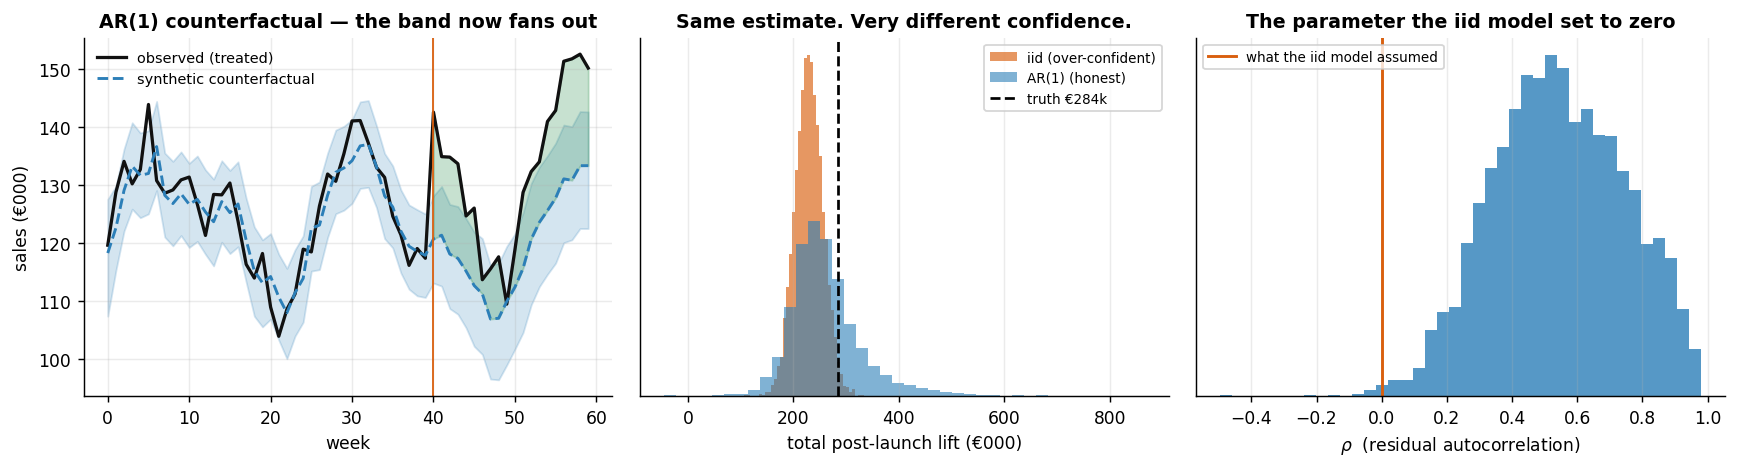

In [8]:
# The same synthetic control, with an AR(1) residual — and the post-period error propagated forward.
# Everything downstream (§5x, §6's euro decision) uses THIS fit from here on: it is the shipped model.
sc_iid, effect_iid, total_post_iid = sc, effect, total_post        # keep the broken one, for the comparison

sc = load_or_run("07_sc_ar1", lambda: est.synthetic_control_ar1(y_tr, donors, pre, post, seed=1, **SC),
                 inputs=dict(seed=SEED, model="ar1", **SC))
print(f"AR(1) SC convergence: {sc['convergence']['summary']}")
cf = sc["counterfactual_samples"]; effect = sc["effect_samples"]
total_post = effect[:, post].sum(1)
rho_post = sc["rho_samples"]

# The §5 diagnosis cells above deliberately keep the IID eff_mean — they are diagnosing the iid
# model. From here on, everything must describe the model we actually SHIP, so recompute the
# weekly gap summaries from the AR(1) fit. (Depth A's bake-off reads these: without this line it
# would grade the estimator we just discarded.)
eff_mean_iid, eff_lo_iid, eff_hi_iid = eff_mean, eff_lo, eff_hi
eff_mean = effect.mean(0)
eff_lo, eff_hi = np.quantile(effect, [0.05, 0.95], 0)

rho_lo, rho_hi = np.quantile(rho_post, [0.05, 0.95])
print(f"\nrho posterior: {rho_post.mean():.2f}  90% [{rho_lo:.2f}, {rho_hi:.2f}]  "
      f"— P(rho > 0) = {(rho_post > 0).mean():.0%}")
print("The data had this persistence all along. The iid model simply refused to look at it.\n")

lo_i, hi_i = np.quantile(total_post_iid, [0.05, 0.95])
lo_a, hi_a = np.quantile(total_post, [0.05, 0.95])
print(f"{'model':<26}{'total lift':>12}{'90% interval':>22}{'width':>9}{'covers truth?':>15}")
for lab, tp, lo, hi in [("iid likelihood (§4)", total_post_iid, lo_i, hi_i),
                        ("AR(1) likelihood (§5z)", total_post, lo_a, hi_a)]:
    print(f"{lab:<26}{tp.mean():>11.0f}k  [{lo:>7.0f}k, {hi:>7.0f}k]{hi - lo:>8.0f}k"
          f"{('yes' if lo <= true_total <= hi else 'NO'):>15}")
print(f"{'planted truth':<26}{true_total:>11.0f}k")

# The verdict that matters is not this panel — it is coverage across many worlds (§5's multi-seed check).
print(f"\nAcross the {len(ms)} fresh panels, the nominal-90% interval on the TOTAL actually covered "
      f"the truth:\n  iid   {ms.tot_cov_iid.mean():.0%}   <- a 90% interval that is right "
      f"{ms.tot_cov_iid.mean():.0%} of the time is not a 90% interval"
      f"\n  AR(1) {ms.tot_cov_ar1.mean():.0%}   <- this one is.")

fig, ax = plt.subplots(1, 3, figsize=(13.5, 3.7))
plots.sc_counterfactual_plot(ax[0], t, y_tr, cf, launch, xlabel="week", ylabel="sales (€000)",
                             title="AR(1) counterfactual — the band now fans out")
ax[1].hist(total_post_iid, bins=40, color=plots.ORANGE, alpha=0.65, density=True, label="iid (over-confident)")
ax[1].hist(total_post, bins=40, color=plots.BLUE, alpha=0.60, density=True, label="AR(1) (honest)")
ax[1].axvline(true_total, color="black", ls="--", lw=1.5, label=f"truth €{true_total:.0f}k")
ax[1].set_xlabel("total post-launch lift (€000)"); ax[1].set_yticks([])
ax[1].set_title("Same estimate. Very different confidence."); ax[1].legend(fontsize=7.5)
ax[2].hist(rho_post, bins=40, color=plots.BLUE, alpha=0.8, density=True)
ax[2].axvline(0, color=plots.ORANGE, lw=1.6, label="what the iid model assumed")
ax[2].set_xlabel(r"$\rho$  (residual autocorrelation)"); ax[2].set_yticks([])
ax[2].set_title("The parameter the iid model set to zero"); ax[2].legend(fontsize=7.5)
fig.tight_layout()

**Read the three panels left to right.** The counterfactual band now *fans out* as the post-period runs
on — the honest picture of a forecast whose error persists rather than resetting every Monday. The middle
panel is the whole notebook in one image: the two posteriors sit a fraction of a standard deviation apart
on the estimate (**€229k** iid vs **€262k** AR(1), against a design-based sd of €101k) and tell wildly
different stories about how much to trust it — a 90% interval **87k** wide against one **222k** wide, and
only the second one contains the planted **€284k**. The right-hand panel shows the parameter the iid model
had silently pinned to zero, with the data's opinion of it plotted on top: $\rho$ posterior mean **0.54**,
90% interval **[0.21, 0.87]**, $P(\rho > 0) = 100\%$.

**What the fix bought, precisely.** Not accuracy — the point estimate barely moved, because the causal work
was done by §3's identification and the simplex, which both models share. What it bought is a **nominal-90%
interval that is actually right about 90% of the time** — **88%** across the 24 fresh panels — in place of
one that was right **50%** of the time. That is the difference between an interval and a decoration.

**The lesson generalises past this notebook, and it is the one to carry into §6.** When a Bayesian interval
fails, the reflex "Bayes was too confident" is almost always wrong. The prior was not the problem — it never
is, in a well-identified problem with real data. The *likelihood* was the problem: it made a claim about the
error structure that the data flatly contradicted. Bayesian inference is not a machine for being humble; it
is a machine for propagating exactly the assumptions you feed it. Feed it "the weeks are independent" and it
will hand you back a beautifully calibrated posterior *for a world that does not exist*.

Which is also why the classical arm looked so good a moment ago: the placebo/design-based interval never
used a likelihood at all. It got its uncertainty from re-running the estimator on worlds where the truth is
known to be zero. That is a genuinely different — and genuinely valuable — source of authority, and §5x now
puts all three side by side.


### 5x · Point estimate vs posterior — what the Bayesian layer actually bought

Step 0 produced a lift estimate and a placebo interval with no likelihood, no prior and no sampler. §4
produced a posterior that turned out to be over-confident, and §5z produced one that is not. All three
target the *same* estimand — the total post-launch lift — so lay them side by side on it, and then do the
thing that actually settles which **uncertainty** statement to believe: count how often each interval
covers the planted truth across the fresh panels of the multi-seed check. Nothing below is asserted; all
of it is measured.

In [9]:
# --- 5x · Three intervals on ONE estimand: the total post-launch lift -----------------------------
# The classical placebo interval, the iid posterior (§4), and the AR(1) posterior (§5z). Everything is
# computed: the point estimates, the widths, and — the head-to-head that settles it — the COVERAGE of
# each interval on the same fresh panels used in §5.
from scipy.stats import norm

post_lo_i, post_hi_i = np.quantile(total_post_iid, [0.05, 0.95])
post_lo_a, post_hi_a = np.quantile(total_post, [0.05, 0.95])
post_lo, post_hi = post_lo_a, post_hi_a        # the SHIPPED model; §6 and the book export read these

# Design-based coverage on the SAME panels as §5 (seeds 100+s). SLSQP only — no MCMC.
def _placebo_coverage():
    cov = []
    for s in range(len(ms)):
        sd_, te_, _lz, tl_ = dgp.geo_panel(n_weeks=60, launch_week=40, n_dmas=30, lift_pct=0.12, seed=100 + s)
        sl = sd_.values.T; ti = list(sd_.columns).index(tl_)
        pg_, rg_, _p = est.placebo_in_space(sl, ti, pre, post, pre_rmse=None, rmse_multiple=5.0)
        tot_ = rg_[post].sum(); pl_ = pg_[:, post].sum(1)
        lo_, hi_ = tot_ - np.quantile(pl_, 0.95), tot_ - np.quantile(pl_, 0.05)
        cov.append(bool(lo_ <= float(te_[post].sum()) <= hi_))
    return cov

cov_ri = load_or_run("07_placebo_coverage", _placebo_coverage, inputs=dict(n=len(ms), rmse_multiple=5.0))

rows5x = [
    ("classical SC (SLSQP) · placebo interval", total_cl, ri_lo, ri_hi, float(np.mean(cov_ri))),
    ("Bayesian SC · iid posterior (§4)", float(total_post_iid.mean()), float(post_lo_i), float(post_hi_i),
     float(ms.tot_cov_iid.mean())),
    ("Bayesian SC · AR(1) posterior (§5z)", float(total_post.mean()), float(post_lo_a), float(post_hi_a),
     float(ms.tot_cov_ar1.mean())),
]
print(f"SAME estimand — total lift over the {n_post} post-launch weeks. Planted truth EUR {true_total:.0f}k.\n")
print(f"{'':<42}{'est':>7}{'5%':>8}{'95%':>8}{'width':>8}{'truth?':>8}{'coverage':>10}")
for lab, e, lo, hi, cov in rows5x:
    print(f"{lab:<42}{e:>7.0f}{lo:>8.0f}{hi:>8.0f}{hi - lo:>8.0f}"
          f"{('yes' if lo <= true_total <= hi else 'NO'):>8}{cov:>9.0%}")

_ests = [total_cl, float(total_post_iid.mean()), float(total_post.mean())]
print(f"\nLOCATION — all three agree. The point estimates span EUR {max(_ests) - min(_ests):.0f}k, a fraction "
      f"of the design-based sd below. Fixing the likelihood did NOT move the estimate.")

print(f"\nWIDTH — four rival scales for the sd of the {n_post}-week total:")
print(f"  iid posterior sd (§4)                      EUR {total_post_iid.std():>5.0f}k   <- the one that was wrong")
print(f"  AR(1) posterior sd (§5z)                   EUR {total_post.std():>5.0f}k")
print(f"  placebo / design-based sd (this panel)     EUR {placebo_tot.std():>5.0f}k")
print(f"  ACTUAL seed-to-seed sd of the error (§5)   EUR {ms.err_iid.std():>5.0f}k   <- the referee")
print(f"  -> the iid posterior underprices the referee by ~{ms.err_iid.std() / total_post_iid.std():.1f}x.")

print(f"\nCOVERAGE across {len(ms)} fresh panels — the only test that matters (nominal 90%):")
print(f"  iid posterior (§4)                          {ms.tot_cov_iid.mean():>4.0%}   <- not a 90% interval")
print(f"  AR(1) posterior (§5z)                       {ms.tot_cov_ar1.mean():>4.0%}")
print(f"  classical randomization interval            {np.mean(cov_ri):>4.0%}   <- design-based, never used a likelihood")

# The decision quantity — and whether the fix changed the call.
p_go_iid = float((total_post_iid > CAMPAIGN_COST).mean())
p_go_post = float((total_post > CAMPAIGN_COST).mean())
widened = norm.rvs(loc=total_post.mean(), scale=placebo_tot.std(), size=40_000, random_state=7)
dec_post = policy.go_no_go(total_post, CAMPAIGN_COST)
dec_wide = policy.go_no_go(widened, CAMPAIGN_COST)   # same centre, the design-based scale
print(f"\nP(lift > EUR {CAMPAIGN_COST:.0f}k cost) — the number §6 signs off on:")
print(f"  classical                                   not defined")
print(f"  Bayesian posterior, iid (§4)                {p_go_iid:>11.2f}")
print(f"  Bayesian posterior, AR(1) (§5z)             {p_go_post:>11.2f}  -> {dec_post['decision']}")
print(f"  same AR(1) posterior, re-scaled to the design sd {dec_wide['P_value_gt_cost']:>7.2f}  -> {dec_wide['decision']}")
print(f"  ('not defined' is no dodge: a p-value ranks data against a null; it attaches")
print(f"   no probability to a hypothesis about the effect.)")
print(f"  -> the AR(1) call {'HOLDS' if dec_post['decision'] == dec_wide['decision'] else 'FLIPS'} under the "
      f"design-based scale. The likelihood and the design now agree on how")
print(f"     confident we are entitled to be — which is exactly what §5z bought.")

[cache] loaded '07_placebo_coverage' (7s fit, cached 0.4h ago) — nothing re-sampled.
SAME estimand — total lift over the 20 post-launch weeks. Planted truth EUR 284k.

                                              est      5%     95%   width  truth?  coverage
classical SC (SLSQP) · placebo interval       260     192     496     304     yes      88%
Bayesian SC · iid posterior (§4)              229     186     273      87      NO      50%
Bayesian SC · AR(1) posterior (§5z)           262     172     394     222     yes      88%

LOCATION — all three agree. The point estimates span EUR 33k, a fraction of the design-based sd below. Fixing the likelihood did NOT move the estimate.

WIDTH — four rival scales for the sd of the 20-week total:
  iid posterior sd (§4)                      EUR    27k   <- the one that was wrong
  AR(1) posterior sd (§5z)                   EUR    72k
  placebo / design-based sd (this panel)     EUR   101k
  ACTUAL seed-to-seed sd of the error (§5)   EUR    59k   

**1 · On the number itself, all three agree — and none is a hero.** The classical SLSQP fit (**€260k**),
the iid posterior (**€229k**) and the AR(1) posterior (**€262k**) span just **€33k**, a third of the
design-based sd, and they *all* undershoot the planted **€284k** — by 8%, 19% and 8% respectively. That is
not a defect of any one apparatus: the causal work was done by §3's identification and by the simplex, which
all three share, and the undershoot is a property of *synthetic control* itself (§7 keeps it as a caveat).
The Bayesian layer bought **no better a point estimate**. It could not have. Fixing the likelihood did not
move the estimate either — which is exactly the point.

**2 · On the uncertainty, they disagree — and the fix, not the paradigm, is what settles it.** This is the
notebook's real finding, and it is measured rather than argued. Read the coverage column. A nominal-90%
interval that covers the truth on only **half** of fresh worlds is not a 90% interval; the iid posterior was
in that state (**50%**, on an interval only **€87k** wide), and the placebo interval — which never used a
likelihood at all — was the only honest statement on the table (**88%**). That was a genuinely uncomfortable
place to be, and for one section it was the truth. Then §5z put the autocorrelation *into the likelihood*,
and the posterior's interval went back to meaning what it says: **88%**, dead level with the design-based
one. Look at the four rival scales for the sd of the 20-week total and you can see the whole argument in one
column: the iid posterior says **€27k**, the AR(1) posterior **€72k**, the design-based placebos **€101k**,
and the referee — the *actual* seed-to-seed sd of the error — says **€59k**. The iid model underpriced the
referee by ~**2.2×**; the AR(1) model is, if anything, a touch conservative.

So the correct conclusion is **not** "the classical arm wins", and it is emphatically not "Bayes is
over-confident". It is sharper and more useful than either:

> When a Bayesian interval under-covers, suspect the **likelihood**, not the paradigm and not the prior.
> The prior did nothing here — swap it and nothing moves. The likelihood did everything, because it is the
> only place where a claim about the *error structure* gets made, and that claim is what a cumulative total
> is made of.

**3 · Why the classical arm was still right to be trusted.** It got its uncertainty from *re-running the
estimator on worlds where the truth is known to be zero* — the placebo distribution — rather than from a
parametric story about the errors. That is design-based inference, and its power is precisely that it is
**agnostic** about the error structure it never had to model. It cannot be wrong about autocorrelation
because it never made a claim about autocorrelation. Keep it. Not as a rival to the posterior, but as the
**referee** that tells you whether your likelihood is lying to you — which, this time, it was.

**4 · What each one is *for*, which is the thing to walk out with.** The posterior is what the euro decision
in §6 consumes, because $P(\text{lift} > \text{cost})$ is a statement only a posterior can make and every
budget meeting demands one — and the cell above shows the call is now robust to *which* honest scale you
use: re-price the AR(1) posterior at the wider design-based sd and $P$ moves 0.21 → 0.35, the decision
**holds**. The design-based interval is what tells you whether to *believe* that posterior. Use the
posterior for the decision, and design-based inference for your confidence in it.


## 6 · Decide, in euros

The campaign cost **€300k**. Everything the notebook has produced so far now collapses into a
single object: the **posterior over total incremental sales** across the 20 post-launch weeks
(`total_post`, in €000). The rollout question is *not* "is the lift positive?" — Depth B's placebo
permutation answers that — but **"what is the probability the lift beats what we paid?"**, because
a real-but-too-small effect still loses money at national scale.

**The decision rule** (`policy.go_no_go`, the cookbook's standard): read
$P(\text{value} > \text{cost})$ off the posterior and act on a stated convention —

- $P > 0.9$ → **GO** — sure enough to act without buying more evidence;
- $P < 0.5$ → **NO-GO** — more likely than not the campaign doesn't pay at this price;
- in between → **TEST FURTHER** — the honest middle where the effect may well be real but the
  *economics* are not yet settled.

Alongside the probability it reports the expected **net value** ($\mathbb E[\text{value}] -
\text{cost}$, in €000) and the expected **ROI** as a ratio (net ÷ cost, so break-even is 0) —
three views of the same posterior, so nobody has to reverse-engineer the call from a chart.

**How to read the two panels.** *Left*: the posterior of total lift with the €300k cost line —
the mass to the right of the line **is** $P(\text{lift} > \text{cost})$ (the dashed marker is the
true total, which we only know because this is a simulation). *Right*: the same posterior read as
a **headroom curve** — sweep a hypothetical cost $c$ and plot $P(\text{lift} > c)$. Where the
curve crosses the green 0.9 line is the *highest price at which this evidence would already
justify a confident GO* — the number to bring to the media-buying negotiation, not just a yes/no.

{
  "P_value_gt_cost": 0.21,
  "expected_value": 261.93,
  "expected_net_value": -38.07,
  "expected_roi": -0.13,
  "value_lo": 171.9,
  "value_hi": 393.83,
  "cost": 300.0,
  "decision": "NO-GO"
}
headroom — the 0.9 crossing on the right-hand curve: this evidence already clears the GO bar at any price up to €192k, i.e. 36.1% below the €300k we paid.


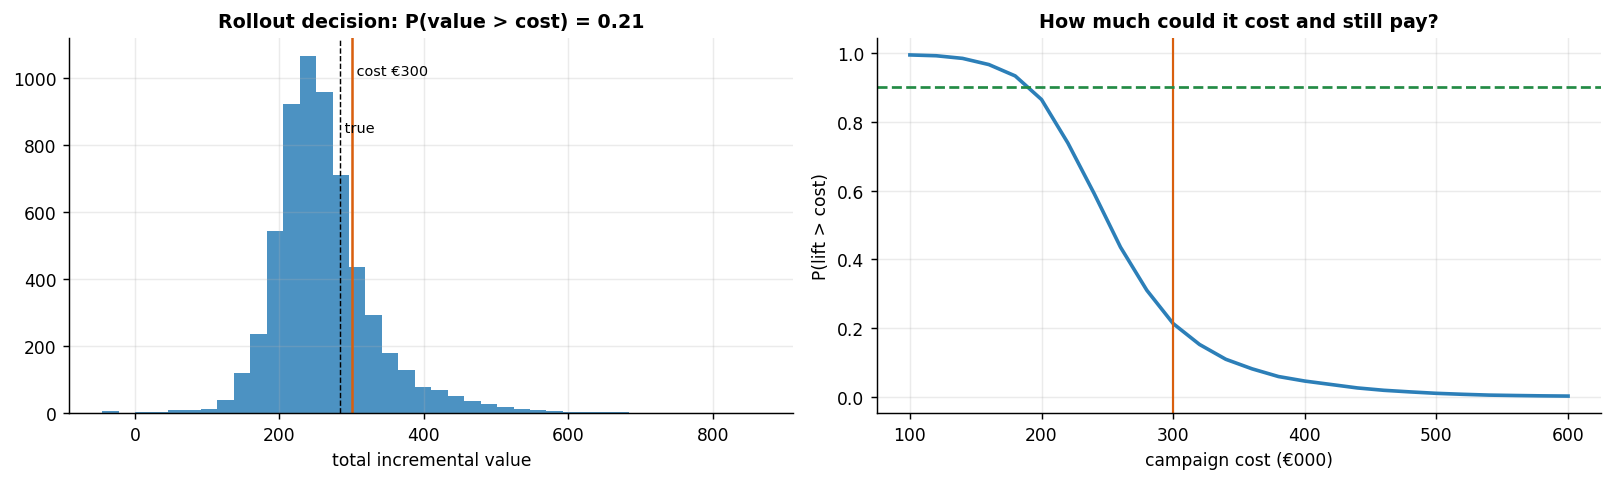

In [10]:
decision = policy.go_no_go(total_post, CAMPAIGN_COST)
cost_grid = np.linspace(100, 600, 26)
p_beats = [(total_post > c).mean() for c in cost_grid]
# The headroom price: P(lift > c) = 0.9 exactly at the posterior's 10th percentile — the highest
# price at which THIS evidence would already be a confident GO. Never eyeballed off the chart.
headroom = float(np.quantile(total_post, 0.10))

fig, ax = plt.subplots(1, 2, figsize=(12.5, 3.8))
plots.decision_hist(ax[0], total_post, CAMPAIGN_COST, true_total=true_total)
ax[1].plot(cost_grid, p_beats, color=plots.BLUE, lw=2)
ax[1].axvline(CAMPAIGN_COST, color=plots.ORANGE, lw=1.2); ax[1].axhline(0.9, color=plots.GREEN, ls="--")
ax[1].set_xlabel("campaign cost (€000)"); ax[1].set_ylabel("P(lift > cost)"); ax[1].set_title("How much could it cost and still pay?")
fig.tight_layout()
def _round(x, nd=2):
    if isinstance(x, float): return round(x, nd)
    if isinstance(x, dict): return {k: _round(v, nd) for k, v in x.items()}
    if isinstance(x, list): return [_round(v, nd) for v in x]
    return x
print(json.dumps(_round(decision), indent=2))
print(f"headroom — the 0.9 crossing on the right-hand curve: this evidence already clears the GO bar "
      f"at any price up to €{headroom:.0f}k, i.e. "
      f"{(CAMPAIGN_COST - headroom) / CAMPAIGN_COST:.1%} below the €{CAMPAIGN_COST:.0f}k we paid.")

**Read-out.** The verdict in this run is **NO-GO**, and the JSON says exactly why: the expected lift
(≈ **€262k**) sits *below* the €300k cost — expected net value ≈ **−€38k**, ROI ≈ **−13%** — and
$P(\text{lift} > \text{cost}) = \mathbf{0.21}$, roughly a one-in-five chance the campaign paid for itself
at this price. Hold this against Depth B without flinching at the apparent contradiction: the placebo
permutation says the effect is **real** (p ≈ 0.03–0.08), while the economics say it **did not clear its
price**. Both are true at once — "statistically significant" and "worth the money" are different questions,
and conflating them is how marginal campaigns get scaled. The headroom curve prices the gap, and the cell
prints the crossing rather than leaving you to eyeball it: the 0.9 bar is cleared at any price up to
**€192k**, i.e. **36% below** the €300k we paid. Had the campaign cost €192k, this same evidence would
already be a confident GO. At €300k, the evidence buys conviction that *something* happened, not conviction
that it *paid*.

And read that 0.21 with §5x's verdict in hand — the right way round. It comes from the **AR(1)** posterior,
whose interval on the total covers 88% of fresh panels, so its precision is *earned*, not optimistic. §5x
stress-tests it by re-scaling the same posterior to the wider design-based sd: $P$ moves 0.21 → 0.35 and the
call **holds**. Note also which way the old, broken model erred: §4's iid posterior would have printed
$P = 0.01$ — an even more emphatic NO-GO, because its band is not merely too narrow but centred €33k lower.
Repairing the likelihood did not rescue the campaign. It made the NO-GO one we are *entitled* to state.


**A NO-GO still has a price tag: the value of information.** A NO-GO is a verdict about *this campaign at
this price*, not a full stop — and it must not end as a shrug either. The deliverable is still an answer to
*"what evidence would settle this, and is it worth buying?"* Two tools, both computed below:

- **VOI (value of information).**
  $\text{VOI} = \mathbb E\big[\max(V - c,\, 0)\big] - \max\big(\mathbb E[V] - c,\, 0\big)$ — the
  expected gain from deciding *after* the uncertainty resolves versus committing now on the mean.
  Intuition: with the posterior centred below the cost line, committing now means walking away and
  banking nothing; perfect foresight would still let us *take* the campaign in the worlds where the lift
  turns out to clear the price. VOI is that recovered upside, averaged over the posterior. It is the most a
  *perfectly informative* test could add in expected decision value — i.e. an **upper bound on any
  confirmatory-test budget**.
- **Test sizing.** A second geo test treating $k$ independent markets tightens the posterior
  roughly as $1/\sqrt{k}$ — it **sharpens** the estimate around the same mean; it doesn't move it.
  So "how big must the test be?" becomes: *the smallest $k$ whose tightened posterior reaches*
  $P(\text{lift} > \text{cost}) \ge 0.9$. Watch what that arithmetic does when the mean sits on the
  **wrong side** of the price, as it now does: shrinking the spread around €262k pulls mass *away* from
  "it cleared €300k", not toward it. More markets buy more certainty that the campaign **doesn't** pay.
  And two hidden assumptions live inside the $1/\sqrt{k}$ anyway, both flattering the test: it treats the
  $k$ market-level estimates as **independent** with equal variance — but this whole world is built on
  *shared* macro factors, so the $k$ gap estimates share estimation error and the *effective* $k$ is
  smaller than the nominal one — and it assumes a second test would land on the same mean. So read any
  computed $k$ as a **lower bound**, and read a *missing* $k$ as the harder truth it is.


Value of information: resolving the cost-line uncertainty is worth ~€14k of expected decision value.
Even a large confirmatory test would not reach 0.90 at this point estimate — the effect sits too close to cost.


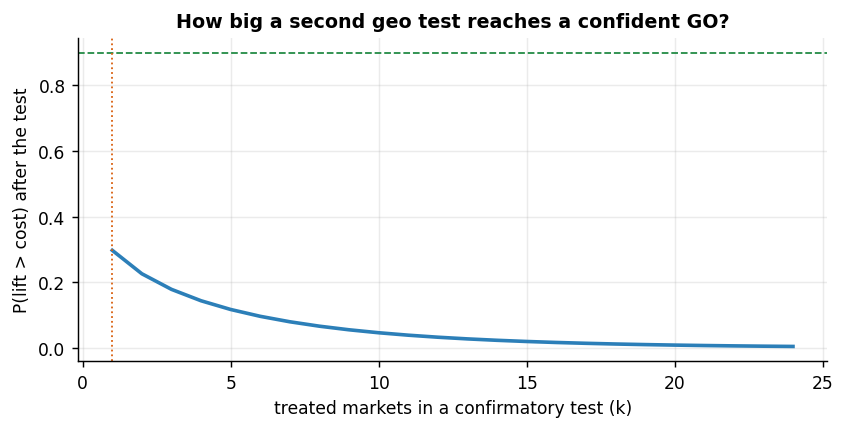

In [11]:
# Value of information & test-sizing: the decision is borderline, so what is a confirmatory geo test
# worth, and how big must it be? VOI = E[max(lift-cost,0)] - max(E[lift]-cost,0) is the expected value
# of resolving the "does it clear cost?" uncertainty before committing.
from scipy.stats import norm
voi = float(np.maximum(total_post - CAMPAIGN_COST, 0).mean() - max(total_post.mean() - CAMPAIGN_COST, 0))
mu, sdev = total_post.mean(), total_post.std()
# A second test averaging k independent treated markets tightens the estimate ~1/sqrt(k) (it sharpens,
# doesn't move it). Find the smallest k reaching a confident GO, P(lift>cost) >= 0.9.
def p_go(k): return float(1 - norm.cdf(CAMPAIGN_COST, loc=mu, scale=sdev / np.sqrt(k)))
k_needed = next((k for k in range(1, 60) if p_go(k) >= 0.9), None)
n_mkts = sales.shape[0]                       # how many markets this world even contains
fig, ax = plt.subplots(figsize=(6.6, 3.4))
ks = np.arange(1, 25); ax.plot(ks, [p_go(k) for k in ks], color=plots.BLUE, lw=2)
ax.axhline(0.9, color=plots.GREEN, ls="--", lw=1); ax.axvline(1, color=plots.ORANGE, ls=":", lw=1)
if k_needed: ax.axvline(k_needed, color=plots.GREEN, ls=":", lw=1); ax.text(k_needed, 0.5, f" k≈{k_needed}", fontsize=8, color=plots.GREEN)
ax.set_xlabel("treated markets in a confirmatory test (k)"); ax.set_ylabel("P(lift > cost) after the test")
ax.set_title("How big a second geo test reaches a confident GO?"); fig.tight_layout()
print(f"Value of information: resolving the cost-line uncertainty is worth ~€{voi:.0f}k of expected decision value.")
if k_needed and k_needed <= n_mkts - 1:
    print(f"A confirmatory geo test averaging ~{k_needed} independent treated markets would tighten the interval\n"
          f"enough to reach P(lift>cost) >= 0.90 — and since the multi-seed check showed this interval is\n"
          f"*optimistic*, treat {k_needed} as a LOWER bound on the test size. That is the experiment to run, not a blind launch.")
elif k_needed:
    print(f"Reaching P(lift>cost) >= 0.90 would take ~{k_needed} independent treated markets — more than this\n"
          f"world contains ({n_mkts} DMAs, one already treated). The honest read: NO feasible single confirmatory\n"
          f"test gets to 0.90 here; extend the post-period, pool repeated tests, or accept a lower confidence bar —\n"
          f"and the multi-seed check says even this arithmetic is optimistic. Still an experiment, never a blind launch.")
else:
    print("Even a large confirmatory test would not reach 0.90 at this point estimate — the effect sits too close to cost.")

**Read-out — sizing the confirmatory test.** VOI ≈ **€14k** in this run. The posterior is centred €38k
*below* the cost line, so the action we would take now — walk away — is the action perfect information would
usually endorse too; the only value in resolving the uncertainty is the upside tail where the lift does
clear €300k, and that tail is worth about **€14k** of expected decision value. That immediately disciplines
the next step: a confirmatory test is rational only if it costs less than ~€14k all-in — no €50k research
programme is justified by these economics.

Now the sizing arithmetic, read straight off the cell above, and it is blunter than a borderline call would
have been: **no test size reaches the 0.9 bar.** The $1/\sqrt{k}$ curve tightens the posterior *around its
own mean of €262k*, and that mean is on the wrong side of the €300k price — so $P(\text{lift} > \text{cost})$
*falls* as $k$ grows, and the cell prints exactly that ("even a large confirmatory test would not reach 0.90
at this point estimate"). Sizing arithmetic cannot rescue a point estimate that is already below the price;
only *new information about the level of the lift* could. That non-answer is more useful than a number of
markets would have been, because it names the real problem.

Which leaves three honest moves, and a fourth that is not on the list. **Renegotiate the price**: at the
**€192k** headroom §6 printed, this same evidence *already* clears the 0.9 bar, so the question to take into
the media negotiation is not "did the campaign work?" but "will you sell it to us for €192k?". **Extend the
post-period, or run the campaign in more markets to move the estimate rather than merely sharpen it** — a
longer post window and fresh markets carry new information about the *level*, which is the only thing that
could change this call. Or **accept the NO-GO at this price** and spend the €300k elsewhere. What is *not*
on the list: a blind national rollout. Depth C pulls this thread together with the launch-date and
donor-pool sensitivities into the one-paragraph verdict a VP signs.


## 7 · Caveats

- **Here synthetic control is high-variance, not conservative.** In this panel the shipped AR(1) estimate
  lands ~8% low (**€262k** against the planted **€284k**); across 24 fresh panels (§5) the mean bias is small
  and *positive* (**+€23k, +7%** of the truth) while the sample-to-sample spread is **large** (sd **€59k**).
  Variance, not bias, is the enemy — and pricing that variance is exactly the job the likelihood has to get
  right. §4's iid likelihood does not: its nominal-90% interval on the total covers **50%** of the time. §5z's
  AR(1) likelihood does: **88%**, level with the design-based placebo interval (**88%**). So the band you
  quote must be the AR(1) one, and the **placebo permutation test** (Step 0's classical inference) stays on
  as the referee that would catch the next mis-specified likelihood — §5x measures all three on the same
  panels rather than asserting anything.
- **The AR(1) fix is itself a model.** It earns calibrated coverage *here* because the true error is a
  persistent, random-walk-driven offset that AR(1) approximates well ($\rho$ posterior mean 0.54). A
  different error structure would need a different likelihood. The transferable lesson is **check the
  coverage**, not "always use AR(1)".
- **Pre-fit is a gate, not a formality.** High pre-RMSE ⇒ the post gap is uninterpretable; no
  Bayesian machinery fixes a bad donor pool. In this panel the gate *fails narrowly* (pre-RMSE €4.15k vs a
  €3.8k bar) — the design sits at the edge of its resolution, which is part of why §6's call is a NO-GO.
- **No-anticipation and no-spillover are assumptions.** Anticipation is stress-tested by
  placebo-in-time in Depth B; spillover is *invisible to every placebo*, so Depth B stress-tests it
  by simulation instead — planted spillover **attenuates** the estimate (SC under-states, never
  inflates), and the fix is donor-pool design, not statistics. Note the asymmetry it creates for a NO-GO:
  attenuation is conservative for a GO call but can *manufacture* a NO-GO out of a campaign that did pay.
- **One treated unit = limited power.** Significance comes from the permutation test, coarse
  with few donors.


---
# Depth A · Why the naive estimators fail

Two tempting shortcuts, both confounded by the shared trend/season/macro wave:

- **Before/after**: post mean − pre mean of the treated DMA — books whatever the shared factors did
  between the two windows as "effect". Which way it errs is not fixed: it depends on where the macro wave
  happened to wander. In *this* panel it wanders against the campaign, so before/after comes in *low*.
- **Treated − average control**: the average control has the wrong factor loadings, so it
  doesn't cancel the common wave cleanly — and taken as a raw level difference it doesn't even cancel the
  markets' different baselines.

Synthetic control is the fix: a *weighted* control chosen to match pre-launch.



{
  "true": 14.2,
  "before/after": 7.2,
  "treated - avg ctrl": 19.3,
  "DiD vs avg ctrl": 10.3,
  "synthetic control": 13.1
}


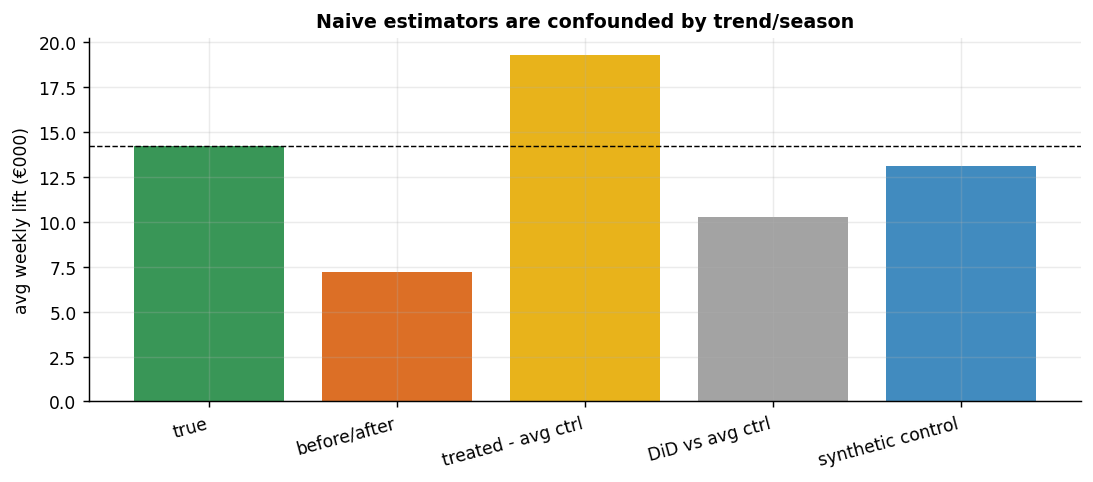

In [12]:
naive_prepost = y_tr[post].mean() - y_tr[pre].mean()
naive_avgctrl = (y_tr[post] - donors[:, post].mean(0)).mean()
# Difference-in-differences vs the average control: subtracts the shared pre-period level too, so it
# removes the trend the level-difference leaves in — isolating the *factor-loading* mismatch that only
# a reweighted synthetic can fix.
naive_did = ((y_tr[post] - donors[:, post].mean(0)).mean()
             - (y_tr[pre] - donors[:, pre].mean(0)).mean())
sc_avg = eff_mean[post].mean()
bake = {"true": true_avg, "before/after": float(naive_prepost),
        "treated - avg ctrl": float(naive_avgctrl), "DiD vs avg ctrl": float(naive_did),
        "synthetic control": float(sc_avg)}
fig, ax = plt.subplots(figsize=(8.5, 3.8))
cols = [plots.GREEN, plots.ORANGE, plots.GOLD, plots.GREY, plots.BLUE]
ax.bar(list(bake.keys()), list(bake.values()), color=cols, alpha=0.9); ax.axhline(true_avg, color="k", ls="--", lw=0.8)
ax.set_ylabel("avg weekly lift (€000)"); ax.set_title("Naive estimators are confounded by trend/season")
plt.setp(ax.get_xticklabels(), rotation=15, ha="right"); fig.tight_layout()
print(json.dumps({k: round(v,1) for k,v in bake.items()}, indent=2))

**Read-out.** Against a true **€14.2k/week**: **before/after** lands at **€7.2k** — it books the shared
factors' movement between the two windows, and in this panel that movement ran *against* the campaign, so
the naive number comes in at half the truth. (A useful corrective to the folk version of this bias: the
trend bias has no fixed sign, it simply has nothing to do with the campaign.) **Treated − average control**
lands at **€19.3k** — it differences *nothing* out, so it carries the raw between-market level gap and
overstates by a third. **DiD vs the average control** (**€10.3k**) removes the shared trend and the level
gap and does much better, but the average control still has the wrong factor loadings, so a residual bias
survives. **The reweighted synthetic control wins outright** at **€13.1k** — within **€1.1k** of the truth,
and the only estimator on the chart that is not off by several times that. The ranking by absolute error is
unambiguous: SC (€1.1k off) ≪ DiD (€3.9k) < treated − avg (€5.1k) < before/after (€7.0k). (The SC bar is the
model we actually ship — §5z's AR(1) fit — not the discarded iid one.) Same data, four estimates — the
estimator *is* the identification strategy.



---
# Depth B · Placebo inference — is the gap statistically real?

Step 0 already ran this test and printed its p-value; it is the classical arm's *entire* inferential
apparatus, so it deserves the box opened. Recall the question, which is a **permutation** question rather
than a standard-error one (with one treated market there is no standard error to have):

> *If the campaign had no effect, how unusual would a post-launch gap this big be, just by chance?*

**Placebo-in-space**, drawn out. Pretending in turn that *each donor market* was the treated one gives a
whole family of gap paths — none of them from a market that actually ran a campaign — and the left panel
plots them all: the grey spaghetti is the null, the coloured line is our metro. The right panel is the same
comparison on Abadie's scale-free statistic (post/pre RMSE ratio; Step 0 defines both refinements — the
pre-fit filter and the ratio — and why each is needed). Two things worth checking that a single p-value
hides, and that this cell prints:

- **How many donors survived the pre-fit filter** (here **24 of 29**), and therefore how coarse the
  reference distribution is. With ~30 markets the p-value is *granular*: it cannot resolve below roughly
  1/30 no matter how strong the effect is. One treated unit buys limited power, and no amount of Bayesian
  machinery would buy more.
- **Whether the verdict depends on the filter cutoff** (2×, 5×, 20× the treated unit's pre-RMSE) — and
  read the printed sweep, because it *does* move, in exactly the direction Abadie's filter exists to
  prevent. Tightening from 5× to 2× *sharpens* the raw-gap p (**0.080 → 0.045**): the well-matched
  placebos are the same placebos, and dropping the marginal ones removes noise rather than evidence.
  Loosening to 20× readmits donors whose own synthetic cannot track them at all — broken fits with huge
  gaps in *both* directions — and they dilute the reference distribution until **p ≈ 0.23**. That is not a
  fragile result; it is a **mis-specified test**, and it is the reason the filter is part of the method
  rather than a knob to tune. The defensible reading of the sweep is: the verdict is stable across every
  cutoff that keeps the comparison honest, and it dissolves as soon as the comparison stops being honest.


placebo-in-space kept 24/29 donors (dropped 5: pre-RMSE > 5x the treated fit)
placebo p vs filter cutoff: 2x -> p=0.045  ·  5x -> p=0.080  ·  20x -> p=0.233  (tighter filters compare only well-matched placebos and do not blunt the test; a loose 20x filter admits broken synthetics and dilutes it)
placebo p (gap) = 0.080 [add-one permutation, treated excluded from placebos]  ·  RMSE-ratio p = 0.033 [Abadie rank/N, treated included]  (treated ratio 4.3 vs placebo median 1.3; the treated market ranks 1/30 on the RMSE ratio. The two p-values differ because the gap test is TWO-SIDED: the treated has the largest positive gap, but one placebo posts a larger |gap| on the downside, and |.| counts it.)


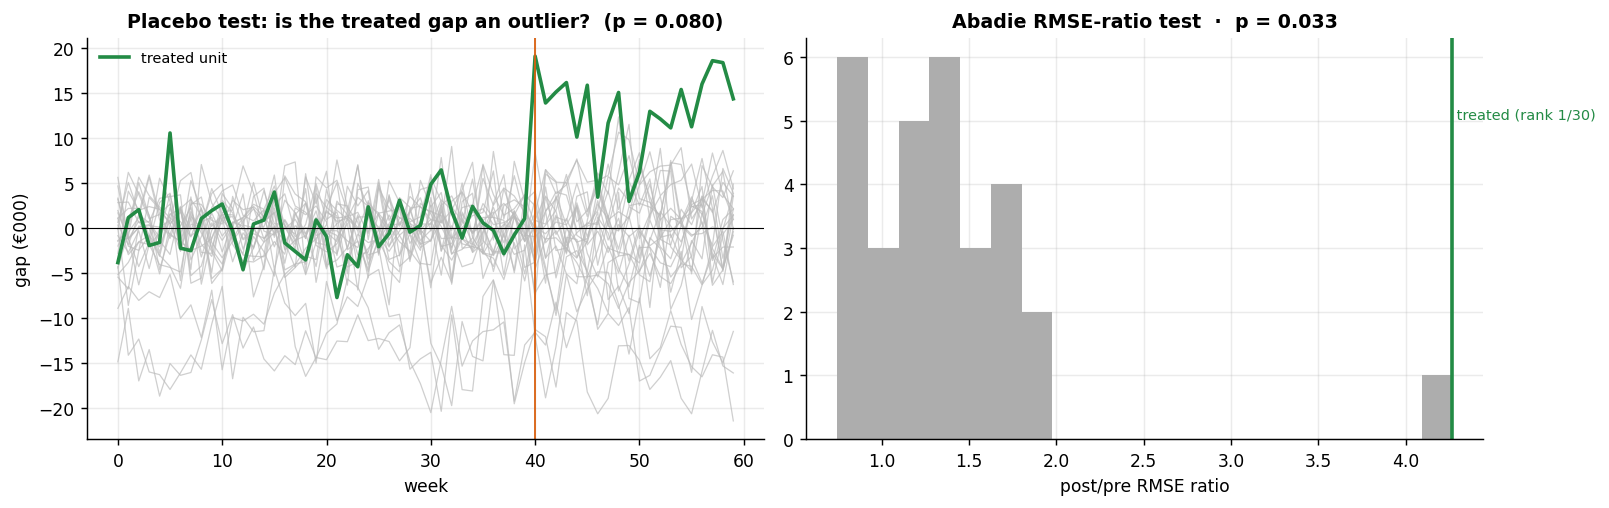

In [13]:
# placebo_gaps / real_gap / p_space / ratios / treated_ratio / p_ratio all come from Step 0 — the same
# refits, computed once. Here we PLOT them, and stress-test the one arbitrary knob: the pre-fit filter.
fig, ax = plt.subplots(1, 2, figsize=(12.5, 4))
plots.placebo_spaghetti(ax[0], t, placebo_gaps, real_gap, launch, p_space, xlabel="week", ylabel="gap (€000)")
ax[1].hist(ratios, bins=20, color=plots.GREY, alpha=0.8); ax[1].axvline(treated_ratio, color=plots.GREEN, lw=2)
ax[1].text(treated_ratio, ax[1].get_ylim()[1]*0.8, f" treated (rank {rank}/{len(ratios)})", fontsize=8, color=plots.GREEN)
ax[1].set_xlabel("post/pre RMSE ratio"); ax[1].set_title(f"Abadie RMSE-ratio test  ·  p = {p_ratio:.3f}")
fig.tight_layout()
n_kept = len(placebo_gaps); n_donors = sales.shape[0] - 1
# Is the verdict sensitive to the (somewhat arbitrary) RMSE filter cutoff?
sens = {m: est.placebo_in_space(sales, treated_idx, pre, post, pre_rmse=None, rmse_multiple=m)[2] for m in (2.0, 5.0, 20.0)}
print(f"placebo-in-space kept {n_kept}/{n_donors} donors (dropped {n_donors - n_kept}: pre-RMSE > 5x the treated fit)")
print("placebo p vs filter cutoff: " + "  ·  ".join(f"{m:g}x -> p={p:.3f}" for m, p in sens.items()) + "  (tighter filters compare only well-matched placebos and do not blunt the test; a loose 20x filter admits broken synthetics and dilutes it)")
print(f"placebo p (gap) = {p_space:.3f} [add-one permutation, treated excluded from placebos]  ·  "
      f"RMSE-ratio p = {p_ratio:.3f} [Abadie rank/N, treated included]  "
      f"(treated ratio {treated_ratio:.1f} vs placebo median {np.median(ratios):.1f}; "
      f"the treated market ranks {rank}/{len(ratios)} on the RMSE ratio. The two p-values differ "
      f"because the gap test is TWO-SIDED: the treated has the largest positive gap, but one placebo "
      f"posts a larger |gap| on the downside, and |.| counts it.)")

**Two p-values, reconciled.** The cell prints two significance numbers — **0.080** (raw gap) and **0.033**
(RMSE ratio) — and they differ because they use different bookkeeping *and* a different statistic. The
**raw-gap permutation** p is a two-sided *add-one* permutation: the treated market counts as one draw of its
own null and is *excluded* from the 24 surviving reference placebos, and what is ranked is the **absolute**
mean post-launch gap. Our metro has the largest *positive* gap of any market in the panel (**+€13.0k/week**;
no placebo beats it on the upside), but one placebo posts a bigger excursion in the *other* direction
(|gap| ≈ €15.3k), and a two-sided test counts it — hence (1+1)/(24+1) = 0.080 rather than 1/25 = 0.040.
**Abadie's RMSE-ratio** p is a rank statistic that keeps the treated market *in* the denominator and divides
its post-period fit by its pre-period fit: on that scale-free statistic the treated market ranks **1st of
30** (ratio **4.3** against a placebo median of **1.3**), giving 1/30 = 0.033. So the two numbers are two
honest bookkeepings of the same evidence, and both reject at the 10% level. We lead with the
**RMSE-ratio**: it is scale-free and penalizes placebos that simply fit badly *everywhere*, so a
poor-pre-fit donor can't masquerade as a sharp post-launch jump — and, as here, a badly-fitting donor's
large *negative* wobble can't inflate the p-value of a genuine positive lift.

**Placebo-in-time.** A second falsification: pretend the campaign launched *before* it did (a
fake week inside the pre-period). The estimated "effect" should be ≈ 0 — a non-zero fake effect
would mean the method invents lift (anticipation or overfitting).


placebo-in-time avg gap €1.7k  vs  pre-fit RMSE €5.06k (should be ≈ 0, and it is well within the pre-fit noise) — no spurious pre-effect.


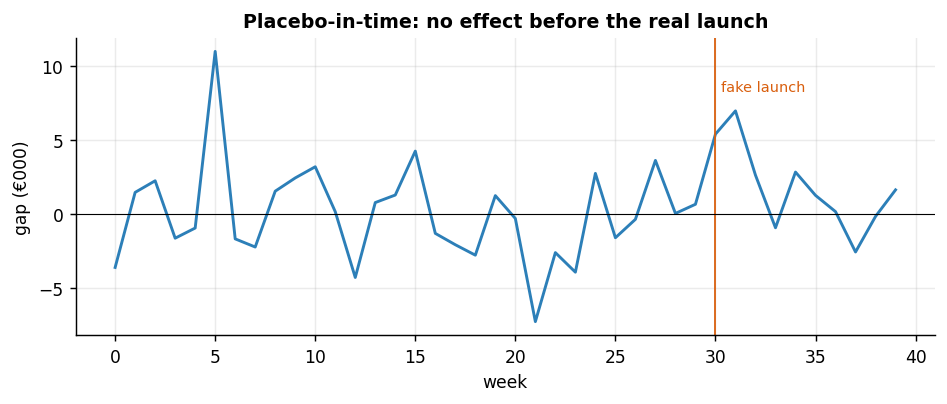

In [14]:
FAKE = launch - 10
gap_fake, _ = est.sc_effect_slsqp(y_tr[:launch], donors[:, :launch], slice(0, FAKE), slice(FAKE, launch))
fake_effect = float(gap_fake[FAKE:launch].mean())
fig, ax = plt.subplots(figsize=(7.5, 3.2))
ax.plot(t[:launch], gap_fake, color=plots.BLUE, lw=1.6); ax.axvline(FAKE, color=plots.ORANGE, lw=1); ax.axhline(0, color="k", lw=0.6)
ax.text(FAKE+0.3, ax.get_ylim()[1]*0.7, "fake launch", color=plots.ORANGE, fontsize=8)
ax.set_xlabel("week"); ax.set_ylabel("gap (€000)"); ax.set_title("Placebo-in-time: no effect before the real launch")
fig.tight_layout()
print(f"placebo-in-time avg gap €{fake_effect:.1f}k  vs  pre-fit RMSE €{sc['pre_rmse']:.2f}k "
      f"(should be ≈ 0, and it is well within the pre-fit noise) — no spurious pre-effect.")

**Spillover — stress-testing the one assumption the placebos cannot touch.** The assumption table
in §3 was honest that placebo-in-space *cannot* detect spillover: if the campaign leaks into donor
markets, every placebo refit is contaminated in exactly the same way, so nothing looks unusual. But
the simulator can do what no real dataset can — rerun the same world with spillover *planted*.
Below, a fraction $\varphi$ of the true lift $\Delta_t$ leaks into five "neighbouring" donor
markets ($Y_{jt} \mathrel{+}= \varphi\,\Delta_t$ for $j$ in the neighbour set) and we refit.
First-order prediction *before* running it: the contaminated donors rise, so the synthetic
counterfactual rises, so the measured gap **shrinks** by roughly the spilled weight,

$$\text{bias} \;\approx\; -\,\varphi \sum_{j \in \text{neighbours}} w_j \;\times\; \text{lift},$$

i.e. spillover makes synthetic control **under-state** a real campaign — attenuation toward "no
effect", the opposite of the false-positive failure most people fear.

In [15]:
# Spillover stress test: leak a fraction phi of the true lift into 5 "neighbour" donors, refit,
# and watch the direction of the bias. Same deterministic SLSQP fitter as the LOO check — no MCMC,
# so the whole sweep costs milliseconds; FAST just uses a coarser phi grid.
phis = [0.0, 0.25, 0.5] if FAST else [0.0, 0.1, 0.25, 0.5]
neigh = list(range(5))                       # the 5 "neighbouring" donors (first five in the pool)
rows_sp = []
for phi in phis:
    d_sp = donors.copy(); d_sp[neigh] += phi * true_effect      # the campaign leaks next door
    g_sp, w_sp = est.sc_effect_slsqp(y_tr, d_sp, pre, post)
    rows_sp.append({"phi": phi, "est_total_k": g_sp[post].sum(),
                    "weight_on_neighbours": w_sp[neigh].sum()})
sp = pd.DataFrame(rows_sp)
print(sp.round(2).to_string(index=False), f"   (true total €{true_total:.0f}k)")
base, w0 = sp.est_total_k.iloc[0], sp.weight_on_neighbours.iloc[0]
meas = sp.est_total_k.iloc[-1] - base
pred = -phis[-1] * w0 * base                 # first-order: -phi x (weight on spilled donors) x lift
print(f"attenuation at phi={phis[-1]}: measured €{meas:+.0f}k vs first-order prediction "
      f"-phi·(Σ neighbour weights)·lift = €{pred:+.0f}k")
# the design fix promised in the §3 table, executed once: EXCLUDE the suspect neighbours and refit
d_sp = donors.copy(); d_sp[neigh] += phis[-1] * true_effect
keep = [k for k in range(donors.shape[0]) if k not in neigh]
g_ex, _ = est.sc_effect_slsqp(y_tr, d_sp[keep], pre, post)
print(f"excluding the 5 neighbours at phi={phis[-1]} restores the estimate to €{g_ex[post].sum():.0f}k "
      f"(contaminated pool: €{sp.est_total_k.iloc[-1]:.0f}k; clean pool: €{base:.0f}k)")
print("Read-out: spillover into donors raises the synthetic, so SC UNDER-states the")
print("lift — attenuation, not inflation. Conservative for a GO call, but it can")
print("turn a true GO into a NO-GO. And because no placebo can flag it, the fix is")
print("DESIGN, not statistics: exclude adjacent / media-overlapping donors up")
print("front — as just shown, a clean-but-smaller pool beats a bigger contaminated one.")

 phi  est_total_k  weight_on_neighbours
0.00       260.46                  0.17
0.10       255.58                  0.17
0.25       248.25                  0.17
0.50       236.04                  0.17    (true total €284k)
attenuation at phi=0.5: measured €-24k vs first-order prediction -phi·(Σ neighbour weights)·lift = €-22k
excluding the 5 neighbours at phi=0.5 restores the estimate to €246k (contaminated pool: €236k; clean pool: €260k)
Read-out: spillover into donors raises the synthetic, so SC UNDER-states the
lift — attenuation, not inflation. Conservative for a GO call, but it can
turn a true GO into a NO-GO. And because no placebo can flag it, the fix is
DESIGN, not statistics: exclude adjacent / media-overlapping donors up
front — as just shown, a clean-but-smaller pool beats a bigger contaminated one.


---
# Depth C · The euro rollout decision & sensitivity

Pull it together into the number a VP signs off on, and pressure-test how the call moves with
the **launch-timing** assumption (did we mis-date the campaign?) and the **donor pool**.


{
  "true_total": 284.43,
  "estimated_total": 261.93,
  "ci90": [
    171.9,
    393.83
  ],
  "pre_rmse": 5.06,
  "p_space": 0.08,
  "p_rmse_ratio": 0.03,
  "placebo_in_time": 1.72,
  "P_lift_gt_cost": 0.21,
  "decision": "NO-GO",
  "eff_donors": 19.93
}


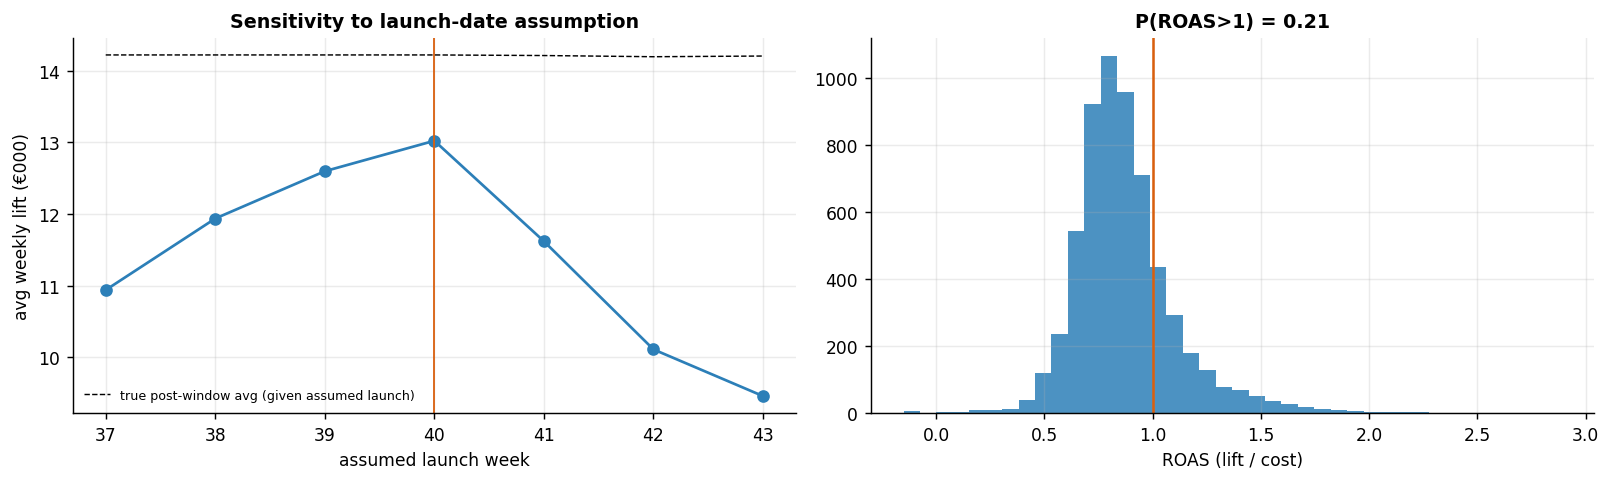

In [16]:
# sensitivity to assumed launch week (±3): does the estimated lift stay stable?
launch_grid = range(launch - 3, launch + 4)
lifts = []
for L in launch_grid:
    g, _ = est.sc_effect_slsqp(y_tr, donors, slice(0, L), slice(L, W))
    lifts.append(g[L:].mean())
fig, ax = plt.subplots(1, 2, figsize=(12.5, 3.8))
ax[0].plot(list(launch_grid), lifts, color=plots.BLUE, marker="o"); ax[0].axvline(launch, color=plots.ORANGE, lw=1)
# L-dependent benchmark: mis-dating folds no-effect weeks into the post window, so the true
# post-window average changes with the assumed launch L.
true_bench = [true_effect[max(L, launch):].mean() for L in launch_grid]
ax[0].plot(list(launch_grid), true_bench, color="k", ls="--", lw=0.8, label="true post-window avg (given assumed launch)")
ax[0].legend(frameon=False, fontsize=7); ax[0].set_xlabel("assumed launch week")
ax[0].set_ylabel("avg weekly lift (€000)"); ax[0].set_title("Sensitivity to launch-date assumption")
# ROAS curve (revenue per euro spent; break-even at 1) — distinct from go_no_go's ROI = net/cost
roas = total_post / CAMPAIGN_COST
ax[1].hist(roas, bins=40, color=plots.BLUE, alpha=0.85); ax[1].axvline(1.0, color=plots.ORANGE, lw=1.4)
ax[1].set_xlabel("ROAS (lift / cost)"); ax[1].set_title(f"P(ROAS>1) = {(roas>1).mean():.2f}")
fig.tight_layout()
result = {"true_total": true_total, "estimated_total": float(total_post.mean()),
          "ci90": [float(np.quantile(total_post,0.05)), float(np.quantile(total_post,0.95))],
          "pre_rmse": sc["pre_rmse"], "p_space": p_space, "p_rmse_ratio": p_ratio,
          "placebo_in_time": fake_effect, "P_lift_gt_cost": decision["P_value_gt_cost"],
          "decision": decision["decision"], "eff_donors": float(eff_n)}
print(json.dumps(_round(result), indent=2))

### The one-paragraph decision

> The campaign drove a **real** incremental lift — and it still did **not** clear its price. The synthetic
> tracks the treated market before launch (pre-launch gap ≈ **€0.5k**/week, no systematic mis-fit), though
> the pre-fit gate **fails narrowly** (pre-RMSE **€4.15k** against the **€3.8k** bar of a third of the weekly
> lift): this design sits at the edge of its resolution, and everything below is stated in that light. The
> blend spreads its weight across ~**20** effective donors (no single market dominates) and is robust to
> dropping any single donor (leave-one-out totals stay within **€239–276k** against the same-fitter SLSQP
> baseline of **€260k**). Nudging the *assumed* launch date does shift the estimate — but that is mechanical,
> not fragility: mis-dating folds no-effect weeks into the post window and dilutes the average lift, so the
> peak at the true launch week is itself a diagnostic. The post gap is the largest *positive* excursion of
> any market on the raw-gap **placebo permutation** test and ranks **1st of 30** on the scale-free
> RMSE-ratio test (raw-gap p = **0.080**, RMSE-ratio p = **0.033**; Depth B reconciles them), and the time
> placebo shows no spurious pre-effect (**€1.7k** against a pre-fit RMSE of €5.1k) — that permutation test is
> the calibrated evidence the effect is real. And yet the euros say no. The shipped AR(1) posterior puts the
> 20-week total at **€262k, 90% [€172k, €394k]** against the **€300k** spend: expected net **−€38k**, ROI
> **−13%**, **P(lift > cost) = 0.21**. The verdict is **NO-GO at this price** — not "the campaign did
> nothing", but "it did not do *enough* to be worth €300k". This same evidence clears the 0.9 GO bar at any
> price up to **€192k**, so the move is to **renegotiate the buy**, not to scale it — and *not* to buy a
> bigger confirmatory test, which cannot help once the point estimate is already on the wrong side of the
> cost line.

**Method summary.** Step 0's classical read — Abadie's SLSQP simplex weights plus placebo/permutation
inference — reaches essentially the same lift as the Bayesian fit (**€260k** vs **€262k**) and, on the
measure that decides it, the same *calibration*: **88%** coverage of the total on 24 fresh panels, against
the AR(1) posterior's **88%**. That parity was *not* there a section ago: §4's first Bayesian model, with an
iid likelihood, covered **50%**, and §5x's coverage table is what caught it. So the lesson this notebook
teaches is not "the classical arm wins" — it is that when a posterior's interval under-covers, the
**likelihood** is the suspect, not the paradigm and not the prior. §5z rewrote the likelihood with an AR(1)
error and the posterior earned its interval back without moving the estimate by more than a fraction of a
standard deviation. Keep the design-based placebos on the payroll not as a rival but as the **referee**: they
never modelled the errors, so they cannot be wrong about them, and they are how you find out that your
likelihood is lying. Then use the posterior for the one thing only a posterior can do — P(lift > cost), the
number §6 signs. **On real data:** notebook **07b** runs this same design on a real Google geo experiment;
Abadie's California Proposition 99 study remains the canonical public panel to practise on.


---
## Book export

The book chapter built from this notebook (`book/chapters/geo_lift.tex`) does not retype a single
number. Every figure it prints — every euro amount, coverage rate, p-value, table cell and plot —
is *emitted* below by `cmp.report` into `book/build/results.json`, from which `book/build.py`
generates `macros.tex`, the booktabs tables and the vector figures the chapter `\input`s. A number
that goes stale is impossible; a number that goes *missing* is a LaTeX compile error rather than a
silent hole. The cell adds no output of its own — the notebook above is unchanged.


In [17]:
# ---------------------------------------------------------------- Book export (cmp.report)
# The book chapter never retypes a number: every figure it prints is emitted HERE, from this
# executed run, into book/build/results.json -> macros.tex (see src/cmp/report.py). A missing
# macro is a LaTeX compile error, never a silent hole. Figures are re-rendered in book style
# (vector PDF, no in-figure title — the caption does that work) and closed immediately, so this
# cell changes nothing the notebook shows above.
import matplotlib as mpl
from cmp import report as R

def V(k, v, **kw):
    return R.value(f"nb07.{k}", v, **kw)

def K(x, nd=0):
    return f"{x:,.{nd}f}"

# --- the world, and the planted truth -------------------------------------------------
V("n_dmas", int(sales.shape[0]), fmt="d")
V("n_donors", int(donors.shape[0]), fmt="d")
V("n_weeks", int(W), fmt="d")
V("launch_week", int(launch), fmt="d")
V("n_post", int(n_post), fmt="d")
V("lift_pct", 12, fmt="d", note="planted proportional lift, per cent")
V("true_total", true_total, unit="EUR000", fmt=",.0f")
V("true_avg", true_avg, unit="EUR000", fmt=".1f")
V("cost", CAMPAIGN_COST, unit="EUR000", fmt=",.0f")

# --- Step 0 · the classical arm --------------------------------------------------------
V("cl_total", total_cl, unit="EUR000", fmt=",.0f")
V("cl_avg", avg_cl, unit="EUR000", fmt=".1f")
V("cl_pre_rmse", pre_rmse_cl, unit="EUR000", fmt=".2f")
V("cl_eff_donors", eff_n_cl, fmt=".1f")
V("cl_n_material", int((w_cl > 0.01).sum()), fmt="d")
V("cl_err", total_cl - true_total, unit="EUR000", fmt="+,.0f")
V("cl_err_pct", 100 * (total_cl - true_total) / true_total, fmt="+.0f")
V("ri_lo", ri_lo, unit="EUR000", fmt=",.0f")
V("ri_hi", ri_hi, unit="EUR000", fmt=",.0f")
V("ri_width", ri_hi - ri_lo, unit="EUR000", fmt=",.0f")
V("p_ratio", p_ratio, fmt=".3f")
V("p_gap", p_space, fmt=".3f")
V("treated_ratio", treated_ratio, fmt=".1f")
V("placebo_median_ratio", float(np.median(ratios)), fmt=".1f")
V("treated_rank", int(rank), fmt="d")
V("n_units", int(len(ratios)), fmt="d")
V("placebo_kept", int(n_kept), fmt="d")
V("placebo_dropped", int(n_donors - n_kept), fmt="d")
V("placebo_sd", float(placebo_tot.std()), unit="EUR000", fmt=".0f")
V("p_filter_two", sens[2.0], fmt=".3f")
V("p_filter_five", sens[5.0], fmt=".3f")
V("p_filter_twenty", sens[20.0], fmt=".3f")

# --- §4 / §5z · the Bayesian arm, BOTH likelihoods -------------------------------------
# `bayes_*` is the SHIPPED model (AR(1), §5z). `iid_*` is the misspecified first attempt (§4),
# kept because the chapter's whole argument is the contrast between them. Emitting both under
# explicit names is deliberate: when `total_post` was re-bound from the iid fit to the AR(1) fit,
# a macro called `bayes_sd` would otherwise have silently changed meaning and every sentence in
# the chapter built on it would have quietly become false.
V("bayes_total", float(total_post.mean()), unit="EUR000", fmt=",.0f")
V("bayes_lo", float(post_lo), unit="EUR000", fmt=",.0f")
V("bayes_hi", float(post_hi), unit="EUR000", fmt=",.0f")
V("bayes_width", float(post_hi - post_lo), unit="EUR000", fmt=",.0f")
V("bayes_sd", float(total_post.std()), unit="EUR000", fmt=".0f")
V("rho_post", float(rho_post.mean()), fmt=".2f")
V("rho_lo", float(np.quantile(rho_post, 0.05)), fmt=".2f")
V("rho_hi", float(np.quantile(rho_post, 0.95)), fmt=".2f")

V("iid_total", float(total_post_iid.mean()), unit="EUR000", fmt=",.0f")
V("iid_lo", float(post_lo_i), unit="EUR000", fmt=",.0f")
V("iid_hi", float(post_hi_i), unit="EUR000", fmt=",.0f")
V("iid_width", float(post_hi_i - post_lo_i), unit="EUR000", fmt=",.0f")
V("iid_sd", float(total_post_iid.std()), unit="EUR000", fmt=".0f")
V("width_ratio", float((post_hi - post_lo) / (post_hi_i - post_lo_i)), fmt=".1f")
V("bayes_pre_rmse", float(sc["pre_rmse"]), unit="EUR000", fmt=".2f")
V("bayes_eff_donors", float(eff_n), fmt=".1f")
V("n_draws", int(SC["draws"] * SC["chains"]), fmt="d")
V("rhat", sc["convergence"]["max_rhat"], fmt=".3f")
V("ess", sc["convergence"]["min_ess_bulk"], fmt=",.0f")
V("divergences", int(sc["convergence"]["n_divergences"]), fmt="d")
V("gate_ref", float(gate_ref), unit="EUR000", fmt=".1f")
V("gate", gate)
V("pre_gap_mean", float(eff_mean[pre].mean()), unit="EUR000", fmt=".2f")
V("loo_lo", float(min(loo)), unit="EUR000", fmt=",.0f")
V("loo_hi", float(max(loo)), unit="EUR000", fmt=",.0f")

# --- §5 · multi-seed calibration and the mechanism -------------------------------------
V("n_panels", int(len(ms)), fmt="d")
V("seed_bias", float(ms.err.mean()), unit="EUR000", fmt="+,.0f")
V("seed_bias_pct", 100 * float(ms.err.mean() / ms["true"].mean()), fmt="+.0f")
V("seed_sd", float(ms.err.std()), unit="EUR000", fmt=".0f")
V("week_cov", 100 * float(ms.wk_cov_iid.mean()), fmt=".0f")
V("week_cov_arone", 100 * float(ms.wk_cov_ar1.mean()), fmt=".0f")
V("total_cov", 100 * float(ms.tot_cov_iid.mean()), fmt=".0f")     # the iid model's TOTAL coverage
V("total_cov_arone", 100 * float(ms.tot_cov_ar1.mean()), fmt=".0f")  # the AR(1) model's — the fix
V("seed_sd_arone", float(ms.err_ar1.std()), unit="EUR000", fmt=".0f")
V("bias_arone", float(ms.err_ar1.mean()), unit="EUR000", fmt="+,.0f")
V("ri_cov", 100 * float(np.mean(cov_ri)), fmt=".0f")
V("sd_believed", float(sd_believed), unit="EUR000", fmt=".0f")
V("sd_actual", float(sd_actual), unit="EUR000", fmt=".0f")
V("sd_ratio_panels", float(sd_actual / sd_believed), fmt=".1f")
V("underprice", float(ms.err_iid.std() / total_post_iid.std()), fmt=".1f")
V("placebo_sd_err_pct", 100 * abs(float(placebo_tot.std()) - float(ms.err.std())) / float(ms.err.std()), fmt=".0f")
V("acf_pre_one", float(acf_pre[0]), fmt="+.2f")
V("acf_pre_two", float(acf_pre[1]), fmt="+.2f")
V("acf_pre_three", float(acf_pre[2]), fmt="+.2f")
V("acf_noise_band", 2 / np.sqrt(res_pre.size), fmt=".2f")
V("rho_one", float(rho[0]), fmt=".2f")
V("rho_eight", float(rho[-1]), fmt=".2f")
V("n_placebo_worlds", int(E.shape[0]), fmt="d")
V("est_diff", abs(total_cl - float(total_post.mean())), unit="EUR000", fmt=".0f")
V("est_diff_pct", 100 * abs(total_cl - float(total_post.mean())) / true_total, fmt=".0f")

# --- §6 · the euro decision ------------------------------------------------------------
V("p_go", decision["P_value_gt_cost"], fmt=".2f")
V("exp_value", decision["expected_value"], unit="EUR000", fmt=",.0f")
V("exp_net", decision["expected_net_value"], unit="EUR000", fmt=",.0f")
V("exp_roi", 100 * decision["expected_roi"], fmt="+.0f")
V("decision", decision["decision"])
V("p_go_rescaled", dec_wide["P_value_gt_cost"], fmt=".2f")
V("decision_rescaled", dec_wide["decision"])
V("voi", float(voi), unit="EUR000", fmt=".0f")
# k_needed is None when NO feasible confirmatory test reaches the 0.90 bar. That is not an edge
# case to paper over — it is a finding. Under the iid likelihood's false confidence the bar looked
# reachable; under the honest AR(1) interval it is not, and the chapter says so in words.
if k_needed is not None:
    V("k_needed", int(k_needed), fmt="d")
    V("k_feasible", "yes")
else:
    V("k_needed", "more than 60")
    V("k_feasible", "no")
V("headroom", float(np.quantile(total_post, 0.10)), unit="EUR000", fmt=",.0f")
V("p_roas", float((roas > 1).mean()), fmt=".2f")

# --- Depths A/B/C · bake-off, time placebo, spillover ----------------------------------
V("naive_ba", bake["before/after"], unit="EUR000", fmt=".1f")
V("naive_avgctrl", bake["treated - avg ctrl"], unit="EUR000", fmt=".1f")
V("naive_did", bake["DiD vs avg ctrl"], unit="EUR000", fmt=".1f")
V("naive_sc", bake["synthetic control"], unit="EUR000", fmt=".1f")
V("placebo_time_gap", float(fake_effect), unit="EUR000", fmt=".1f")
V("placebo_time_week", int(FAKE), fmt="d")
V("sp_phi", float(phis[-1]), fmt=".2f")
V("sp_clean", float(sp.est_total_k.iloc[0]), unit="EUR000", fmt=",.0f")
V("sp_contaminated", float(sp.est_total_k.iloc[-1]), unit="EUR000", fmt=",.0f")
V("sp_excluded", float(g_ex[post].sum()), unit="EUR000", fmt=",.0f")
V("sp_measured", float(meas), unit="EUR000", fmt="+,.0f")
V("sp_predicted", float(pred), unit="EUR000", fmt="+,.0f")
V("sp_neighbour_weight", 100 * float(w0), fmt=".0f")
V("sp_n_neighbours", int(len(neigh)), fmt="d")

# --- tables ----------------------------------------------------------------------------
R.table(pd.DataFrame([
    {"Arm": "Classical SC · placebo interval",
     "Est.": K(total_cl), "5%": K(ri_lo), "95%": K(ri_hi), "Width": K(ri_hi - ri_lo),
     "sd": K(placebo_tot.std()),
     "Truth in?": "yes" if ri_lo <= true_total <= ri_hi else "no",
     "Coverage": f"{np.mean(cov_ri):.0%}"},
    {"Arm": "Bayesian SC · iid posterior (§4)",
     "Est.": K(total_post_iid.mean()), "5%": K(post_lo_i), "95%": K(post_hi_i),
     "Width": K(post_hi_i - post_lo_i), "sd": K(total_post_iid.std()),
     "Truth in?": "yes" if post_lo_i <= true_total <= post_hi_i else "no",
     "Coverage": f"{ms.tot_cov_iid.mean():.0%}"},
    {"Arm": "Bayesian SC · AR(1) posterior (§5z)",
     "Est.": K(total_post.mean()), "5%": K(post_lo), "95%": K(post_hi),
     "Width": K(post_hi - post_lo), "sd": K(total_post.std()),
     "Truth in?": "yes" if post_lo <= true_total <= post_hi else "no",
     "Coverage": f"{ms.tot_cov_ar1.mean():.0%}"},
]), "nb07.compare", align="lrrrrrcc",
    caption=(f"The same estimand, three arms: total post-launch lift over the {n_post} weeks "
             f"(EUR 000; planted truth {true_total:,.0f}). All three point estimates agree; the "
             f"intervals do not. \\emph{{Coverage}} is the share of {len(ms)} fresh panels on which each "
             f"nominal 90\\% interval contained the planted total — and it is the only column that "
             f"settles anything. The iid likelihood's interval is the narrowest and the least often "
             f"right; putting the residual's autocorrelation into the likelihood (AR(1)) restores it."),
    label="tab:sc:compare")

R.table(pd.DataFrame([
    {"Scale for the sd of the 20-week total": "Posterior sd — iid likelihood (§4)",
     "Value": K(total_post_iid.std()), "Source": "likelihood (wrong)"},
    {"Scale for the sd of the 20-week total": "Posterior sd — AR(1) likelihood (§5z)",
     "Value": K(total_post.std()), "Source": "likelihood (fixed)"},
    {"Scale for the sd of the 20-week total": "Placebo / design-based sd (this panel)",
     "Value": K(placebo_tot.std()), "Source": "design"},
    {"Scale for the sd of the 20-week total": "Seed-to-seed sd of the estimation error",
     "Value": K(ms.err_iid.std()), "Source": "the referee"},
]), "nb07.scales", align="lrl",
    caption=(f"Four rival prices for the same uncertainty (EUR 000). The referee is the actual "
             f"sample-to-sample spread of the estimation error across {len(ms)} fresh panels. The iid "
             f"posterior underprices it by a factor of "
             f"{ms.err_iid.std() / total_post_iid.std():.1f}; the design-based placebo scale lands "
             f"within {100 * abs(placebo_tot.std() - ms.err_iid.std()) / ms.err_iid.std():.0f}\\% of "
             f"it without ever writing down a likelihood. Modelling the residual's persistence "
             f"explicitly (AR(1)) brings the likelihood-based price back onto the same scale as both."),
    label="tab:sc:scales")

R.table(pd.DataFrame([
    {"Estimator": "Planted truth", "Avg weekly lift": K(bake["true"], 1), "Error": "--"},
    {"Estimator": "Before / after (treated market only)", "Avg weekly lift": K(bake["before/after"], 1),
     "Error": f"{bake['before/after'] - bake['true']:+.1f}"},
    {"Estimator": "Treated minus average control", "Avg weekly lift": K(bake["treated - avg ctrl"], 1),
     "Error": f"{bake['treated - avg ctrl'] - bake['true']:+.1f}"},
    {"Estimator": "Difference-in-differences vs average control", "Avg weekly lift": K(bake["DiD vs avg ctrl"], 1),
     "Error": f"{bake['DiD vs avg ctrl'] - bake['true']:+.1f}"},
    {"Estimator": "Synthetic control", "Avg weekly lift": K(bake["synthetic control"], 1),
     "Error": f"{bake['synthetic control'] - bake['true']:+.1f}"},
]), "nb07.naive", align="lrr",
    caption=("Same panel, four estimators (average weekly lift, EUR 000). The shortcuts book the "
             "shared trend and the level gap as campaign effect; only the reweighted control comes "
             "close. The estimator is the identification strategy."),
    label="tab:sc:naive")

_top = np.argsort(-w_mean)[:8]
R.table(pd.DataFrame([
    {"Donor market": donor_labels[i], "SLSQP weight": f"{w_cl[i]:.3f}",
     "Posterior mean weight": f"{w_mean[i]:.3f}"} for i in _top
]), "nb07.weights", align="lrr",
    caption=(f"The eight donors carrying most posterior weight. Abadie's constrained least squares "
             f"concentrates on a sparse handful ({eff_n_cl:.1f} effective donors, $1/\\sum_j w_j^2$); the "
             f"flat Dirichlet prior spreads the same fit over {eff_n:.1f} — more stable out of sample, "
             f"less interpretable as a business object."),
    label="tab:sc:weights")

R.table(pd.DataFrame([
    {"Spillover $\\varphi$": f"{r.phi:.2f}", "Estimated total": K(r.est_total_k),
     "Weight on the contaminated donors": f"{r.weight_on_neighbours:.2f}"}
    for r in sp.itertuples()
]), "nb07.spillover", align="lrr", math_headers=True,
    caption=(f"Spillover attenuates. A fraction $\\varphi$ of the true lift is leaked into "
             f"{len(neigh)} neighbouring donors and the estimator refit (EUR 000; planted truth "
             f"{true_total:,.0f}). Contaminated donors lift the synthetic, so the measured gap "
             f"\\emph{{shrinks}}: synthetic control under-states a real campaign, never inflates it. "
             f"Dropping the suspect donors restores the estimate to {g_ex[post].sum():,.0f}."),
    label="tab:sc:spillover", fmt="%.2f")

# --- figures (book style: vector PDF, no in-figure title, closed so nothing renders inline) ---
with mpl.rc_context(R.book_style()):
    f = plt.figure(figsize=(6.6, 3.2)); a = f.add_subplot(111)
    for j in range(sales.shape[0]):
        a.plot(t, sales[j], color="#cccccc", lw=0.6, alpha=0.7)
    a.plot(t, sales[treated_idx], color="#111", lw=1.8, label=f"{treated_label} (treated)")
    a.axvline(launch, color=plots.ORANGE, lw=1)
    a.set_xlabel("week"); a.set_ylabel("sales (€000)"); a.legend(frameon=False)
    f.tight_layout()
    R.figure(f, "nb07.panel", caption=(
        f"The panel. {sales.shape[0]} markets over {W} weeks, all riding the same trend, seasonal cycle "
        f"and macro random walk; the treated market (dark) receives the campaign in week {launch}. The "
        f"shared macro wave is what makes a before/after comparison worthless and a weighted blend of "
        f"donors possible."), label="fig:sc:panel")
    plt.close(f)

    f = plt.figure(figsize=(6.6, 3.4)); a = f.add_subplot(111)
    a.plot(t, y_tr, color="#111", lw=1.7, label=f"{treated_label} (treated)")
    a.plot(t, cf_cl, color=plots.BLUE, ls="--", lw=1.6, label="synthetic control (SLSQP)")
    a.fill_between(t[post], cf_cl[post], y_tr[post], color=plots.GREEN, alpha=0.25,
                   label="post-launch gap")
    a.axvline(launch, color=plots.ORANGE, lw=1)
    a.set_xlabel("week"); a.set_ylabel("sales (€000)"); a.legend(frameon=False)
    f.tight_layout()
    R.figure(f, "nb07.sc", caption=(
        f"The treated market and its synthetic control. Simplex weights fitted on weeks "
        f"0--{launch - 1} only; the synthetic tracks the treated market to a pre-fit RMSE of "
        f"{pre_rmse_cl:.2f} (EUR 000) before launch, which is the precondition for reading the shaded "
        f"post-launch gap as campaign lift."), label="fig:sc:sc")
    plt.close(f)

    f = plt.figure(figsize=(6.6, 3.4)); a = f.add_subplot(111)
    a.plot(t, eff_mean, color=plots.BLUE, lw=1.8, label="posterior mean gap")
    a.fill_between(t, eff_lo, eff_hi, color=plots.BLUE, alpha=0.2, label="90% posterior band")
    a.plot(t, true_effect, color="k", ls="--", lw=1.2, label="planted lift")
    a.axvline(launch, color=plots.ORANGE, lw=1); a.axhline(0, color="k", lw=0.6)
    a.set_xlabel("week"); a.set_ylabel("weekly lift (€000)"); a.legend(frameon=False)
    f.tight_layout()
    R.figure(f, "nb07.gap", caption=(
        f"Recovery. The weekly gap between the treated market and its posterior counterfactual, against "
        f"the planted lift. The pre-launch gap averages {eff_mean[pre].mean():.2f} (EUR 000), and the "
        f"90\\% posterior-predictive band covers the true path {100 * ms.wk_cov_ar1.mean():.0f}\\% of the time across "
        f"panels — per-week, the likelihood is roughly right. Section~\\ref{{sec:sc:compare}} shows what "
        f"happens when these weeks are summed."), label="fig:sc:gap")
    plt.close(f)

    f = plt.figure(figsize=(6.9, 3.2)); ax2 = f.subplots(1, 2)
    plots.placebo_spaghetti(ax2[0], t, placebo_gaps, real_gap, launch, p_space,
                            xlabel="week", ylabel="gap (€000)")
    ax2[1].hist(ratios, bins=20, color=plots.GREY, alpha=0.8)
    ax2[1].axvline(treated_ratio, color=plots.GREEN, lw=2)
    ax2[1].set_xlabel("post/pre RMSE ratio"); ax2[1].set_ylabel("markets")
    f.tight_layout()
    R.figure(f, "nb07.placebo", caption=(
        f"Design-based inference. \\emph{{Left}}: the same estimator refit on every donor market as if it "
        f"had been treated ({n_kept} of {n_donors} survive Abadie's 5$\\times$ pre-fit filter); the grey "
        f"paths are the distribution of gaps the world produces from noise alone, the coloured path is the "
        f"treated market. \\emph{{Right}}: the same comparison on Abadie's scale-free post/pre RMSE ratio, "
        f"on which the treated market ranks {rank} of {len(ratios)} ($p = {p_ratio:.3f}$)."),
        label="fig:sc:placebo")
    plt.close(f)

    f = plt.figure(figsize=(6.6, 3.0)); a = f.add_subplot(111)
    _lags = [1, 2, 3, 5, 8]
    a.bar([str(l) for l in _lags], rho, color=plots.GREY, alpha=0.9, label="out-of-sample gap error")
    a.bar([str(l) for l in _lags], [0] * len(_lags), color=plots.BLUE)
    a.axhline(0, color=plots.BLUE, lw=1.8, label="what the iid likelihood assumes")
    a.set_ylim(-0.05, 1.05); a.set_xlabel("lag (weeks)")
    a.set_ylabel("autocorrelation of the gap error")
    a.legend(frameon=False, loc="lower left")
    f.tight_layout()
    R.figure(f, "nb07.acf", caption=(
        f"The misspecification, measured. Autocorrelation of the synthetic control's out-of-sample gap "
        f"error, computed on {E.shape[0]} placebo worlds in which the true lift is zero (so the post-launch "
        f"gap \\emph{{is}} the error). It is essentially flat at $\\rho \\approx {rho[0]:.2f}$ out to eight "
        f"weeks: the error is a persistent offset — the unmatched share of the macro random walk — not "
        f"fresh weekly noise. The iid likelihood sets every one of these bars to zero."),
        label="fig:sc:acf")
    plt.close(f)

    f = plt.figure(figsize=(6.9, 3.1)); ax2 = f.subplots(1, 2)
    plots.decision_hist(ax2[0], total_post, CAMPAIGN_COST, true_total=true_total)
    ax2[0].set_xlabel("total lift (€000)"); ax2[0].set_ylabel("posterior draws")
    ax2[1].plot(cost_grid, p_beats, color=plots.BLUE, lw=2)
    ax2[1].axvline(CAMPAIGN_COST, color=plots.ORANGE, lw=1.2)
    ax2[1].axhline(0.9, color=plots.GREEN, ls="--")
    ax2[1].set_xlabel("campaign cost (€000)"); ax2[1].set_ylabel("P(lift > cost)")
    f.tight_layout()
    R.figure(f, "nb07.euro", caption=(   # key != nb07.decision: that name is a scalar (the verdict)
        f"The decision, in euros. \\emph{{Left}}: the posterior of total incremental sales against the "
        f"{CAMPAIGN_COST:,.0f} (EUR 000) campaign cost; the mass to the right of the cost line is "
        f"$P(\\text{{lift}} > \\text{{cost}}) = {decision['P_value_gt_cost']:.2f}$. \\emph{{Right}}: the "
        f"same posterior read as a headroom curve. The 0.9 bar is cleared only at a price of "
        f"{np.quantile(total_post, 0.10):,.0f} or below — the number to take to the media-buying "
        f"negotiation."), label="fig:sc:decision")
    plt.close(f)

print(f"book export: {len([k for k in R.load() if k.startswith('nb07.') and not k.startswith('nb07b')])} "
      f"keys emitted to book/build/results.json")


book export: 118 keys emitted to book/build/results.json
